In [ ]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import importlib

import matplotlib.pyplot ass plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    video_tools
)
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz
from src.STAR_utils.visualization_tools import qa_visualization as videoviz

from src import (
    datasets,
    prompt_formatters as pf
)


import logging
import sys

# Get your existing logger
logger = logging.getLogger("data_preprocessing")

# Add a handler if it doesn't already have one
if not logger.handlers:
    handler = logging.StreamHandler(sys.stdout)  # Use stdout for Jupyter
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    handler.setFormatter(formatter)
    logger.addHandler(handler)

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")

#-------------- 200 sub-set
# SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_200.jsonl"

# # The file below has been run with a context window of 8_192
# GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_on_geminiSGG_gemini2.5flash_20250804_21:49:00.jsonl"
# # The file below has been run with a longer context window 8_192
# GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_200_on_geminiSGG_gemini25flash_20250825_15:48:00.jsonl"
# GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_200_20250804_19:21:00.jsonl"


# -------------- 1000 subset
#SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_gemini25flash_1000.jsonl"

# GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250805_15:48:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250806_17:30:00.jsonl"

#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250825_18:30:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250826_18:30:00.jsonl"

#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250805_15:48:00.jsonl"
#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250828_17:48:00.jsonl"
#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250830_14:52:00.jsonl"


# -------------- 1000 subset
# -------------- Longer OutTokens gen SGG
# -------------- Longer OutTokens GU
SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_gemini2.5flash_1000_OutTokens8192_20250829_22:00:00.jsonl"

GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250830_14:52:00.jsonl"

# 4B
GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250830_14:52:00.jsonl"
# 12B
GEMMA12_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250830_14:52:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    #"Interaction_T1_3485",
    #"Interaction_T4_4181",
    #"Interaction_T2_1847",
]

SHOW_VIDEO = False


Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    token=hugg_auth_token
)


In [3]:
plt.rcParams.update({
    'figure.figsize': (24,8),      # Large figure size for posters
    'font.size': 20,                  # Base font size
    'axes.labelsize': 24,             # Axis label font size
    'axes.labelweight': 'bold',
    'axes.titlesize': 28,             # Title font size
    'xtick.labelsize': 26,            # X-tick label size
    'ytick.labelsize': 26,            # Y-tick label size
    'legend.fontsize': 24,            # Legend font size
    'lines.linewidth': 3,             # Thicker lines
    'lines.markersize': 10,           # Larger markers
})


## Load GT

In [4]:
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(6)
memory usage: 73.7+ KB


## Load predictions - Gemma generated STSG

In [5]:
model_preds = {}


In [6]:
PATH = WORK_DIR / "outputs/gqa_u3_all_sgg_20250711_16:11:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="ollama")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["NeSy"] = [
    {
        "model_name": "Gemma3:4B",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "support_ratio": rp.print_ans_perc(eval_df[eval_df['contains_answer']], gt_df),
        "model_size": 4,
    }
]


Total answers: 1038
Answers following JSON template: 1037
Percentage following JSON template: 99.90%
Answer with a valid alternative: 656
63.26% of the total

Invalid answers: 381
Question type       Total      Accuracy 

Interaction          298        31.21%  
Sequence             291        26.12%  
Prediction           239        27.62%  
Feasibility          220        26.36%  

Average             1048        27.96%  
Question type       Total      Accuracy 

Interaction          196        47.45%  
Sequence             150        50.67%  
Prediction           171        38.60%  
Feasibility          139        41.73%  

Average              656        44.66%  
Question type       Total      Answered 

Interaction          298        65.77%  
Sequence             291        51.55%  
Prediction           239        71.55%  
Feasibility          220        63.18%  
Overall             1048        62.60%  


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
/tmp/ipykernel_364986/3688927541.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df['contains_answer'].fillna(False).astype(bool)


In [7]:
PATH = WORK_DIR / "outputs/vqa_u3_fixorder_video_fps_gemma3:4b-it-qat_20250711_16:16:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="ollama")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)


Total answers: 1039
Answers following JSON template: 1039
Percentage following JSON template: 100.00%
Answer with a valid alternative: 1021
98.27% of the total

Invalid answers: 18


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
/tmp/ipykernel_364986/3224646299.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df['contains_answer'].fillna(False).astype(bool)


In [8]:
model_preds["Direct VideoQA"] = [
    {
        "model_name": "Gemma3:4B",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "model_size": 4,
    }
]


Question type       Total      Accuracy 

Interaction          298        47.99%  
Sequence             291        51.55%  
Prediction           239        41.84%  
Feasibility          220        39.09%  

Average             1048        45.71%  
Question type       Total      Accuracy 

Interaction          293        48.81%  
Sequence             285        52.63%  
Prediction           228        43.86%  
Feasibility          215        40.00%  

Average             1021        46.91%  


## Plots

```json
{"answer": "None of the alternatives are supported by the scene graph."}
```
```json
{"answer": "None of the provided alternatives are supported by the scene graph. The scene graph only describes the man’s observation of the window, and does not provide any information about his ability to interact with it in any way other than looking at it."}
```
```json
{"answer": "I cannot answer the question."}
```
```json
{"answer": "Cannot answer the question"}
```
```json
{"answer": "None of the alternatives are correct."}
```
```json
{"answer": "Cannot answer the question"}
```
```json
{"answer": "Cannot answer the question"}
```
```json
{"answer": "The question cannot be answered."}
```
```json
{"answer": "None of the alternatives accurately describe what happened based on the provided scene graph."}
```
```json
{"answer": "I cannot answer the question."}
```
```json
{"answer": "I cannot answer the question."}
```
```json
{"answer": "Cannot answer the question"}
```
```json
{"answer":

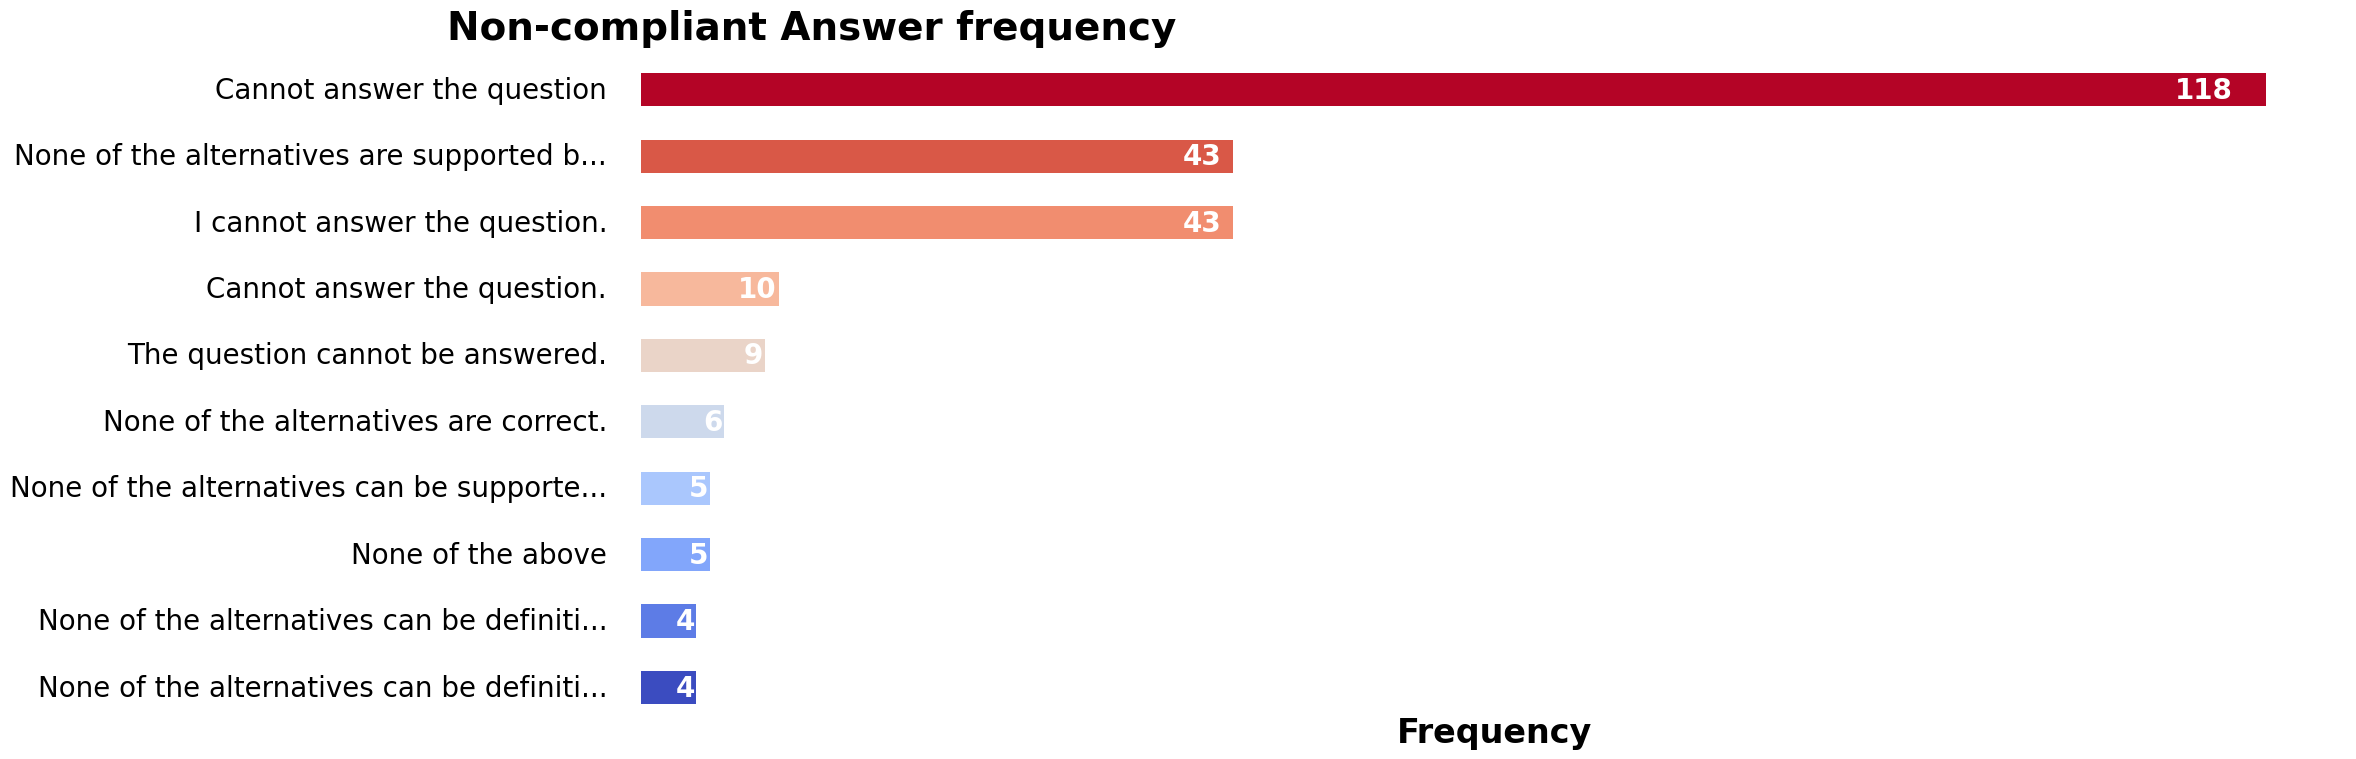

In [9]:
from matplotlib import cm 

nesy_predictions = model_preds['NeSy'][0]['predictions_df']
(nesy_predictions[~nesy_predictions['contains_answer']]['chat_history']
    .apply(lambda x: print(x[-1]['content']))
)


# Your provided pandas Series, getting the top 10
answer_counts = nesy_predictions[~nesy_predictions['contains_answer']]['pred_text'].value_counts().head(10)

# Truncate labels that are too long (40 characters)
def truncate_label(label, max_len=40):
    if len(str(label)) > max_len:
        return str(label)[:max_len] + '...'
    return str(label)

truncated_labels = [truncate_label(label) for label in answer_counts.index]

# Set up colors using the 'coolwarm' colormap
colors = cm.coolwarm(np.linspace(1, 0, len(answer_counts)))

# --- Plotting ---
fig, ax = plt.subplots()#figsize=(8, 5))

# --- Control the bar thickness ---
bar_thickness = 0.5
bars = ax.barh(y=np.arange(len(answer_counts)), width=answer_counts.values, height=bar_thickness, color=colors)

# --- Minimalist Styling ---
ax.grid(False)
ax.set_title("Non-compliant Answer frequency", x=0.1, pad=20, fontweight='bold')
ax.set_xlabel("Frequency")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([]) # Remove default ticks; we draw our own labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# --- Manually place left-justified labels with a margin ---
# This part remains the same as before.
x_margin = -0.02 * ax.get_xlim()[1]
for i, label in enumerate(truncated_labels):
    ax.text(x_margin, i, label,
            ha='right',
            va='center',
)

# --- NEW: Add Frequency Labels inside each bar ---
# We iterate through the bars and the actual data (answer_counts.values)
# to add text annotations.
for i, bar in enumerate(bars):
    # Get the width of the bar (which is the frequency count)
    width = bar.get_width()

    # Place text just inside the end of the bar.
    # We use a small offset (width * 0.98) to give it a little padding from the edge.
    ax.text(width * 0.98,              # X position: 98% of the bar's width
            bar.get_y() + bar.get_height() / 2, # Y position: vertical center of the bar
            f'{int(width)}',           # Text to display (the frequency as an integer)
            ha='right',                # Horizontal alignment
            va='center',               # Vertical alignment
            color='white',             # Text color
            fontweight='bold',         # Make it stand out
                    )                # Adjust font size as needed

# Invert y-axis to have the highest frequency bar at the top
ax.invert_yaxis()
# Adjust the margins to remove excess white space
ax.margins(y=0.01)

# Use a tight layout to ensure our new labels fit
plt.tight_layout()

plt.savefig(f'endtoend_model_negative_ans_freq.svg', format='svg', dpi=300, bbox_inches='tight')


In [10]:
eval_df = model_preds['NeSy'][0]['eval_df']
eval_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
 8   chat_history      1038 non-null   object 
 9   contains_answer   1048 non-null   bool   
 10  pred_text         1048 non-null   object 
dtypes: bool(1), float64(2), object(8)
memory usage: 123.4+ KB


In [11]:
eval_df[eval_df['contains_answer']].groupby(by=lambda x: str(x.split('_')[0]))['question'].count().to_dict()


{'Feasibility': 139, 'Interaction': 196, 'Prediction': 171, 'Sequence': 150}

In [12]:
eval_df = model_preds['Direct VideoQA'][0]['eval_df']
eval_df[eval_df['contains_answer']].groupby(by=lambda x: str(x.split('_')[0]))['question'].count().to_dict()


{'Feasibility': 215, 'Interaction': 293, 'Prediction': 228, 'Sequence': 285}

0
1
2
3
4
5
6
7
8
9


/tmp/ipykernel_364986/2603312702.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(question_type_order)


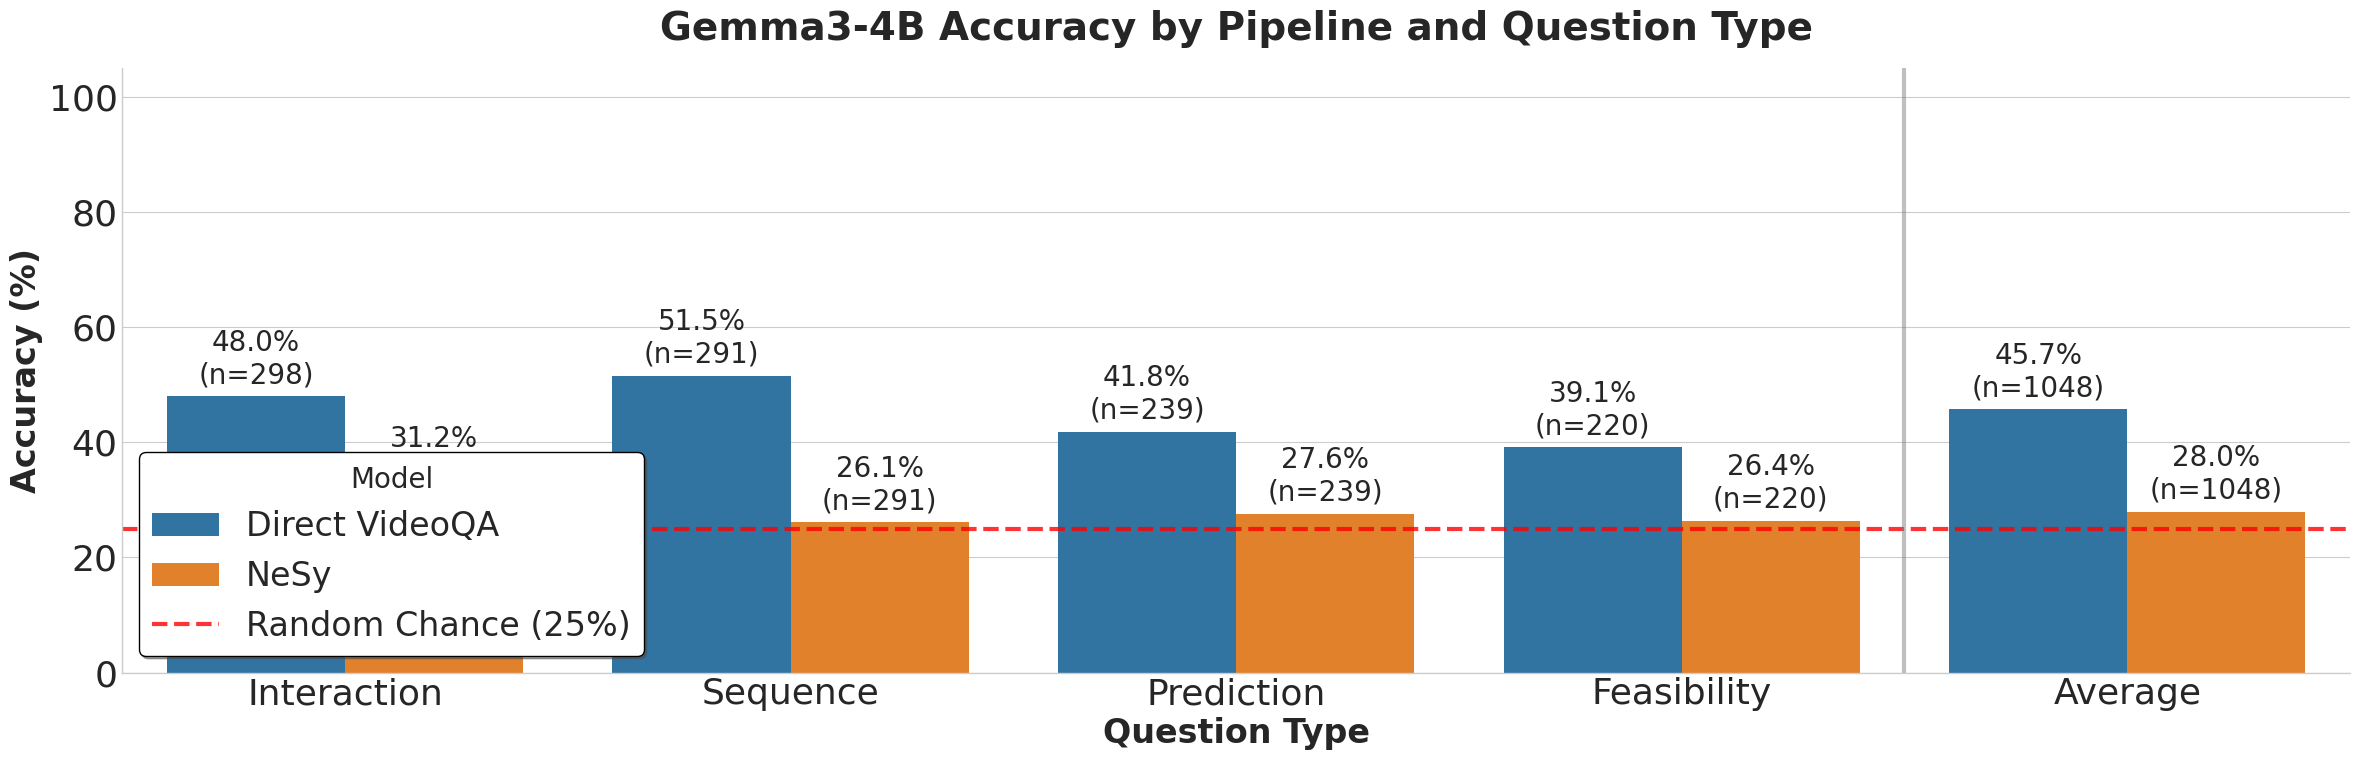

In [13]:
# HYPERPARAMETER: Choose which accuracy metric to plot
ACCURACY_METRIC = "accuracy"  # Options: "accuracy", "accuracy_contains_answer"

# Extract accuracy data for the new list-based structure with question type breakdown
data = []
model_sizes = {}
support_info = {}  # Store support information for each model

for approach_name, models_list in model_preds.items():
    for model_data in models_list:
        if isinstance(model_data, dict) and 'accuracy' in model_data:
            model_name = model_data['model_name']
            model_size = model_data.get('model_size', 0)
            # Use original key name directly
            model_display_name = approach_name  # Use the original key name
            
            # Store model size for sorting
            model_sizes[model_display_name] = model_size
            
            # Check if the selected accuracy metric exists
            if ACCURACY_METRIC not in model_data:
                print(f"Warning: {ACCURACY_METRIC} not found in {model_display_name}, skipping...")
                continue
            
            eval_df = model_data.get('eval_df', None)
            # Calculate support based on accuracy metric
            if ACCURACY_METRIC == "accuracy":
                support = eval_df.shape[0]  # Assuming eval_df.shape[0] is stored
            elif ACCURACY_METRIC == "accuracy_contains_answer":
                support = eval_df['contains_answer'].sum()  # Assuming eval_df['contains_answer'].sum() is stored
                eval_df = eval_df[eval_df['contains_answer']]
            else:
                support = model_data.get('eval_df', None).shape[0]  # Default fallback
            
            # Store support info
            support_info[model_display_name] = support
            
            # Extract accuracy data for each question type from the selected metric
            accuracy_data = model_data[ACCURACY_METRIC]
            
            # Calculate question counts grouped by question type
            question_type_counts = {}
            if eval_df is not None:
                # Group by question_type and sum contains_answer for each group
                question_type_counts = eval_df.groupby(by=lambda x: str(x.split('_')[0]))['question'].count().to_dict()
                # Add total count for Average
                question_type_counts['Average'] = support
            
            # Handle both dictionary and single value formats
            if isinstance(accuracy_data, dict):
                # If it's a dictionary with question types
                for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']:
                    if question_type in accuracy_data:
                        # Get question count for this specific question type
                        question_count = question_type_counts.get(question_type, None)
                        
                        data.append({
                            'Model': model_display_name,
                            'Question_Type': question_type,
                            'Accuracy': accuracy_data[question_type] * 100,  # Convert to percentage
                            'Model_Size': model_size,
                            'Approach': approach_name,
                            'Base_Model': model_name,
                            'Support': support,
                            'Question_Count': question_count
                        })
            else:
                # If it's a single value, treat as overall accuracy
                question_count = question_type_counts.get('Average', support) if question_type_counts else support
                data.append({
                    'Model': model_display_name,
                    'Question_Type': 'Overall',
                    'Accuracy': accuracy_data * 100,  # Convert to percentage
                    'Model_Size': model_size,
                    'Approach': approach_name,
                    'Base_Model': model_name,
                    'Support': support,
                    'Question_Count': question_count
                })

# Create DataFrame
df = pd.DataFrame(data)

# Sort models by size and then by name for consistent ordering
sorted_models = sorted(df['Model'].unique(), 
                      key=lambda x: (model_sizes.get(x, 0), x))
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create the main plot with all question types
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots() #figsize=(16, 9))

# Define question type order based on data structure
available_question_types = df['Question_Type'].unique()
if 'Average' in available_question_types:
    # If we have question type breakdown
    question_type_order = ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']
    question_type_order = [qt for qt in question_type_order if qt in available_question_types]
else:
    # If we have overall accuracy only
    question_type_order = list(available_question_types)

# Filter to available question types for the primary plot
main_df = df[df['Question_Type'].isin(question_type_order)]

# Create color palette based on number of models
n_models = len(sorted_models)

sns.barplot(data=main_df, x='Question_Type', y='Accuracy', hue='Model',
            ax=ax, order=question_type_order)

# Add random chance baseline (25% for 4-choice questions)
ax.axhline(y=25, color='red', linestyle='--', alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars with question counts
for p in ax.patches:
    if p.get_height() > 0:
        # Find the corresponding data point to get question count
        bar_index = ax.patches.index(p)
        print(bar_index)
        # Calculate which question type and model this bar corresponds to
        n_models = len(sorted_models)
        question_type_idx = bar_index % len(question_type_order)
        model_idx = bar_index // len(question_type_order)
        
        if question_type_idx < len(question_type_order):
            current_question_type = question_type_order[question_type_idx]
            current_model = sorted_models[model_idx]
            
            # Find the question count for this specific combination
            matching_rows = main_df[
                (main_df['Question_Type'] == current_question_type) & 
                (main_df['Model'] == current_model)
            ]
            
            if not matching_rows.empty:
                question_count = matching_rows.iloc[0]['Question_Count']
                ax.annotate(f'{p.get_height():.1f}%\n(n={question_count})',
                           (p.get_x() + p.get_width()/2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 5), textcoords='offset points')
            else:
                ax.annotate(f'{p.get_height():.1f}%',
                           (p.get_x() + p.get_width()/2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average (only if Average exists)
if 'Average' in available_question_types and len(question_type_order) > 1:
    avg_position = question_type_order.index('Average') - 0.5
    ax.axvline(x=avg_position, color='gray', linestyle='-',  alpha=0.5)

# Create x-labels (keeping original question type names)
ax.set_xticklabels(question_type_order)

# Styling
metric_display_name = ACCURACY_METRIC.replace('_', ' ').title()
if ACCURACY_METRIC == 'accuracy':
    title = 'Gemma3-4B Accuracy by Pipeline and Question Type'
else:
    title = 'Gemma3-4B Accuracy by Pipeline and Question Type - Only answered questions'

ax.set_title(title, fontweight='bold', pad=20)
ax.set_xlabel('Question Type')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend to include support information
handles, labels = ax.get_legend_handles_labels()
# Create labels with support information
clean_labels = []
for label in labels:
    if label != 'Random Chance (25%)':
        # Add support information to the label
        support = support_info.get(label, 'N/A')
        clean_labels.append(f'{label} (n={support})')
    else:
        clean_labels.append(label)

legend = plt.legend(handles, labels, title='Model', loc='lower left',
                   frameon=True, fancybox=True, shadow=True, 
                   facecolor='white', edgecolor='black', framealpha=1)

plt.tight_layout()
plt.savefig(f'endtoend_model_{ACCURACY_METRIC}_by_question_type.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


0
1
2
3
4
5
6
7
8
9


/tmp/ipykernel_364986/339643037.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(question_type_order)


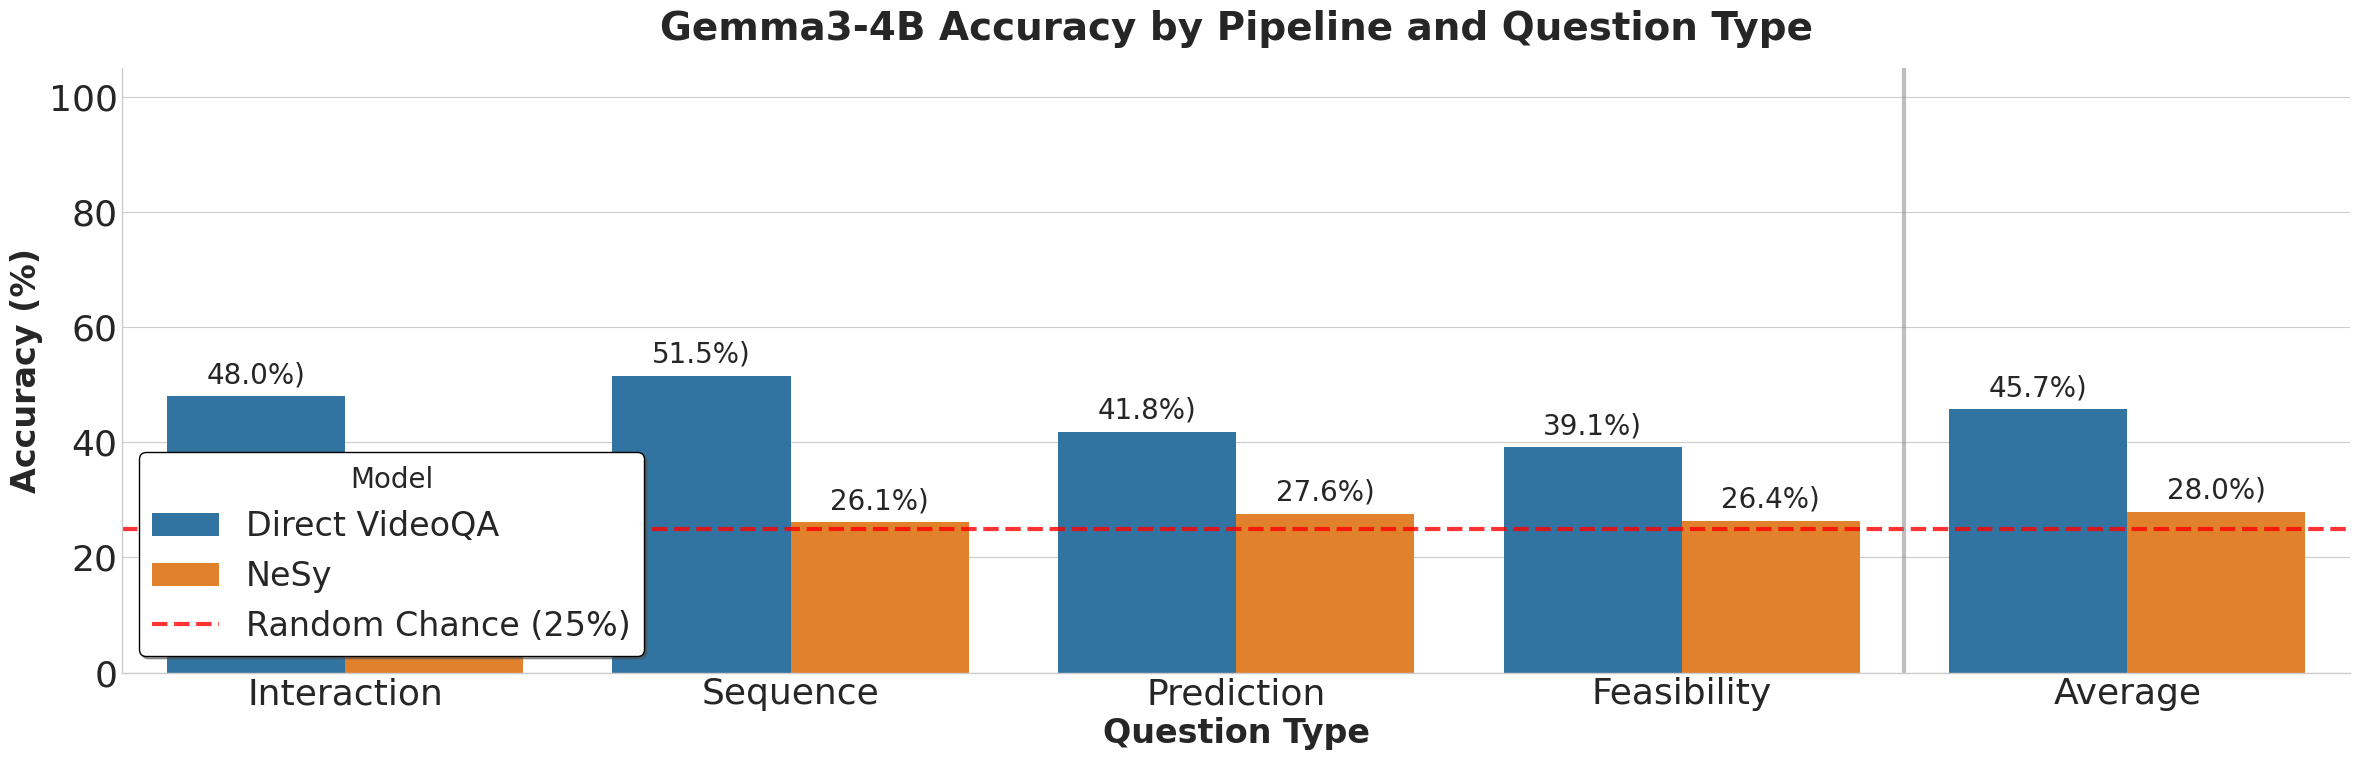

In [14]:
# HYPERPARAMETER: Choose which accuracy metric to plot
ACCURACY_METRIC = "accuracy"  # Options: "accuracy", "accuracy_contains_answer"

# Extract accuracy data for the new list-based structure with question type breakdown
data = []
model_sizes = {}
support_info = {}  # Store support information for each model

for approach_name, models_list in model_preds.items():
    for model_data in models_list:
        if isinstance(model_data, dict) and 'accuracy' in model_data:
            model_name = model_data['model_name']
            model_size = model_data.get('model_size', 0)
            # Use original key name directly
            model_display_name = approach_name  # Use the original key name
            
            # Store model size for sorting
            model_sizes[model_display_name] = model_size
            
            # Check if the selected accuracy metric exists
            if ACCURACY_METRIC not in model_data:
                print(f"Warning: {ACCURACY_METRIC} not found in {model_display_name}, skipping...")
                continue
            
            eval_df = model_data.get('eval_df', None)
            # Calculate support based on accuracy metric
            if ACCURACY_METRIC == "accuracy":
                support = eval_df.shape[0]  # Assuming eval_df.shape[0] is stored
            elif ACCURACY_METRIC == "accuracy_contains_answer":
                support = eval_df['contains_answer'].sum()  # Assuming eval_df['contains_answer'].sum() is stored
                eval_df = eval_df[eval_df['contains_answer']]
            else:
                support = model_data.get('eval_df', None).shape[0]  # Default fallback
            
            # Store support info
            support_info[model_display_name] = support
            
            # Extract accuracy data for each question type from the selected metric
            accuracy_data = model_data[ACCURACY_METRIC]
            
            # Calculate question counts grouped by question type
            question_type_counts = {}
            if eval_df is not None:
                # Group by question_type and sum contains_answer for each group
                question_type_counts = eval_df.groupby(by=lambda x: str(x.split('_')[0]))['question'].count().to_dict()
                # Add total count for Average
                question_type_counts['Average'] = support
            
            # Handle both dictionary and single value formats
            if isinstance(accuracy_data, dict):
                # If it's a dictionary with question types
                for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']:
                    if question_type in accuracy_data:
                        # Get question count for this specific question type
                        question_count = question_type_counts.get(question_type, None)
                        
                        data.append({
                            'Model': model_display_name,
                            'Question_Type': question_type,
                            'Accuracy': accuracy_data[question_type] * 100,  # Convert to percentage
                            'Model_Size': model_size,
                            'Approach': approach_name,
                            'Base_Model': model_name,
                            'Support': support,
                            'Question_Count': question_count
                        })
            else:
                # If it's a single value, treat as overall accuracy
                question_count = question_type_counts.get('Average', support) if question_type_counts else support
                data.append({
                    'Model': model_display_name,
                    'Question_Type': 'Overall',
                    'Accuracy': accuracy_data * 100,  # Convert to percentage
                    'Model_Size': model_size,
                    'Approach': approach_name,
                    'Base_Model': model_name,
                    'Support': support,
                    'Question_Count': question_count
                })

# Create DataFrame
df = pd.DataFrame(data)

# Sort models by size and then by name for consistent ordering
sorted_models = sorted(df['Model'].unique(), 
                      key=lambda x: (model_sizes.get(x, 0), x))
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create the main plot with all question types
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots() #figsize=(16, 9))

# Define question type order based on data structure
available_question_types = df['Question_Type'].unique()
if 'Average' in available_question_types:
    # If we have question type breakdown
    question_type_order = ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']
    question_type_order = [qt for qt in question_type_order if qt in available_question_types]
else:
    # If we have overall accuracy only
    question_type_order = list(available_question_types)

# Filter to available question types for the primary plot
main_df = df[df['Question_Type'].isin(question_type_order)]

# Create color palette based on number of models
n_models = len(sorted_models)

sns.barplot(data=main_df, x='Question_Type', y='Accuracy', hue='Model',
            ax=ax, order=question_type_order)

# Add random chance baseline (25% for 4-choice questions)
ax.axhline(y=25, color='red', linestyle='--', alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars with question counts
for p in ax.patches:
    if p.get_height() > 0:
        # Find the corresponding data point to get question count
        bar_index = ax.patches.index(p)
        print(bar_index)
        # Calculate which question type and model this bar corresponds to
        n_models = len(sorted_models)
        question_type_idx = bar_index % len(question_type_order)
        model_idx = bar_index // len(question_type_order)
        
        if question_type_idx < len(question_type_order):
            current_question_type = question_type_order[question_type_idx]
            current_model = sorted_models[model_idx]
            
            # Find the question count for this specific combination
            matching_rows = main_df[
                (main_df['Question_Type'] == current_question_type) & 
                (main_df['Model'] == current_model)
            ]
            
            if not matching_rows.empty:
                question_count = matching_rows.iloc[0]['Question_Count']
                ax.annotate(f'{p.get_height():.1f}%)',
                           (p.get_x() + p.get_width()/2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 5), textcoords='offset points')
            else:
                ax.annotate(f'{p.get_height():.1f}%',
                           (p.get_x() + p.get_width()/2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average (only if Average exists)
if 'Average' in available_question_types and len(question_type_order) > 1:
    avg_position = question_type_order.index('Average') - 0.5
    ax.axvline(x=avg_position, color='gray', linestyle='-',  alpha=0.5)

# Create x-labels (keeping original question type names)
ax.set_xticklabels(question_type_order)

# Styling
metric_display_name = ACCURACY_METRIC.replace('_', ' ').title()
if ACCURACY_METRIC == 'accuracy':
    title = 'Gemma3-4B Accuracy by Pipeline and Question Type'
else:
    title = 'Gemma3-4B Accuracy by Pipeline and Question Type - Only answered questions'

ax.set_title(title, fontweight='bold', pad=20)
ax.set_xlabel('Question Type')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend to include support information
handles, labels = ax.get_legend_handles_labels()
# Create labels with support information
clean_labels = []
for label in labels:
    if label != 'Random Chance (25%)':
        # Add support information to the label
        support = support_info.get(label, 'N/A')
        clean_labels.append(f'{label} (n={support})')
    else:
        clean_labels.append(label)

legend = plt.legend(handles, labels, title='Model', loc='lower left',
                   frameon=True, fancybox=True, shadow=True, 
                   facecolor='white', edgecolor='black', framealpha=1)

plt.tight_layout()
plt.savefig(f'endtoend_model_{ACCURACY_METRIC}_by_question_type.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


## Loading Qwen 2.5 VL

In [15]:
PATH = WORK_DIR / "outputs/gqa_u3_qwensgg_of_20240722_gemma3:4b-it-qat_20250730_10:21:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="ollama")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["NeSy2"] = [
    {
        "model_name": "Gemma3:4B",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "model_size": 7,
    }
]


Total answers: 1048
Answers following JSON template: 1048
Percentage following JSON template: 100.00%
Answer with a valid alternative: 634
60.50% of the total

Invalid answers: 414
Question type       Total      Accuracy 

Interaction          298        32.21%  
Sequence             291        27.49%  
Prediction           239        30.54%  
Feasibility          220        27.73%  

Average             1048        29.58%  
Question type       Total      Accuracy 

Interaction          180        53.33%  
Sequence             143        55.94%  
Prediction           169        43.20%  
Feasibility          142        42.96%  

Average              634        48.90%  


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [16]:
PATH = WORK_DIR / "outputs/gqa_u3_qwensgg_of_20240722_qwen25vl:7b_20250730_10:21:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="ollama")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["NeSy2"].append(
    {
        "model_name": "Qwen2.5V:7B",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "model_size": 7,
    }
)


Total answers: 1048
Answers following JSON template: 1048
Percentage following JSON template: 100.00%
Answer with a valid alternative: 530
50.57% of the total

Invalid answers: 518
Question type       Total      Accuracy 

Interaction          298        34.56%  
Sequence             291        24.40%  
Prediction           239        26.78%  
Feasibility          220        25.45%  

Average             1048        28.05%  
Question type       Total      Accuracy 

Interaction          174        59.20%  
Sequence             115        61.74%  
Prediction           129        49.61%  
Feasibility          112        50.00%  

Average              530        55.47%  


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [17]:
PATH = WORK_DIR / "outputs/vqa_u3_qwen2.5vl_1000_20250723_15:02:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="ollama")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["Direct VideoQA"].append(
    {
        "model_name": "Qwen2.5VL:7B",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "model_size": 7,
    }
)


Total answers: 1048
Answers following JSON template: 1048
Percentage following JSON template: 100.00%
Answer with a valid alternative: 975
93.03% of the total

Invalid answers: 73
Question type       Total      Accuracy 

Interaction          298        60.74%  
Sequence             291        66.67%  
Prediction           239        58.16%  
Feasibility          220        45.91%  

Average             1048        58.68%  
Question type       Total      Accuracy 

Interaction          281        64.41%  
Sequence             277        70.04%  
Prediction           222        62.61%  
Feasibility          195        51.79%  

Average              975        63.08%  


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [18]:
model_preds['NeSy'][0]['eval_df']['contains_answer'].sum()


656

In [19]:
import pandas as pd

ACCURACY_METRIC = "accuracy_contains_answer"

def latex_row(model, bold_mask=None):
    """
    Generate a LaTeX table row for a model (non-bold model name, unless it's a setting header).
    """
    qtype_order = ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']
    
    # Model name: NOT bold (only settings and max values are bold)
    row_str = f"{model['model_name']}"
    
    acc = model[ACCURACY_METRIC]
    for i, qtype in enumerate(qtype_order):
        val = acc[qtype]
        formatted_val = f"{val * 100:.1f}"
        if qtype == 'Average' and ACCURACY_METRIC == 'accuracy_contains_answer':
            formatted_val += f" ({model['eval_df']['contains_answer'].sum()})"
        if bold_mask and bold_mask[i]:
            formatted_val = f"\\textbf{{{formatted_val}}}"
        row_str += f" & {formatted_val}"
    
    row_str += " \\T\\B \\\\"
    return row_str


# --- Prepare data ---
# Assume model_preds has:
#   'NeSy'        → Gemma3-4B SGG
#   'NeSy2'       → Qwen2.5-7B SGG  
#   'Direct VideoQA'  → Direct VideoQA

setting_map = {
    'NeSy': 'Gemma3-4B SGG - Graph-based QA',
    'NeSy2': 'Qwen2.5-7B SGG - Graph-based QA',
    'Direct VideoQA': 'Direct VideoQA'
}

# Flatten all models to compute global column max
all_models = []
model_settings = []  # to track which setting each model belongs to

for key in ['NeSy', 'NeSy2', 'Direct VideoQA']:
    setting = model_preds[key]
    for model in setting:
        all_models.append(model)
        model_settings.append(key)

# Build numeric matrix for max computation
qtype_order = ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']
values_matrix = []
for model in all_models:
    row_vals = [model['accuracy'][q] for q in qtype_order]
    values_matrix.append(row_vals)

df_vals = pd.DataFrame(values_matrix, columns=qtype_order)
is_max = df_vals.eq(df_vals.max(axis=0), axis=1)  # boolean mask for global max per column

# --- Generate LaTeX ---
latex_lines = []

latex_lines.append(r"\begin{table}[H]")
latex_lines.append(r"\centering")
latex_lines.append(r"\begin{tabular}{|l c c c c c|}")
latex_lines.append(r"\hline")
latex_lines.append(r"\multicolumn{6}{|c|}{\textbf{Experimental Results on Graph-based QA}} \T\B \\")
latex_lines.append(r"\hline")
# Question type headers (only once, not bold except the words themselves as headers)
latex_lines.append(r" & Int. & Seq. & Pr. & Fea. & Avg. (Support) \T\B \\")
latex_lines.append(r"\hline")

global_idx = 0

# Process each setting in order
for key in ['NeSy', 'NeSy2', 'Direct VideoQA']:
    setting_name = setting_map[key]
    models = model_preds[key]
    
    # Experimental setting row: LEFT-ALIGNED, BOLD, spans all columns
    latex_lines.append(rf"\multicolumn{{6}}{{|l|}}{{\textbf{{{setting_name}}}}} \T\B \\")
    latex_lines.append(r"\hline")
    
    # Add model rows for this setting
    for model in models:
        # Get bold mask for this row (True where this row has column max)
        bold_mask = is_max.iloc[global_idx].tolist()
        row_latex = latex_row(model, bold_mask=bold_mask)
        latex_lines.append(row_latex)
        global_idx += 1
    
    # Add double hline after each setting block (as in your example)
    latex_lines.append(r"\hline \hline")

# Replace final "\hline \hline" with single "\hline" before closing
if latex_lines[-1] == r"\hline \hline":
    latex_lines[-1] = r"\hline"

# Close table
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\\[10pt]")
latex_lines.append(r"\caption{Caption}")
latex_lines.append(r"\label{table:full_results}")
latex_lines.append(r"\end{table}")

# Output
latex_table = "\n".join(latex_lines)
print(latex_table)


\begin{table}[H]
\centering
\begin{tabular}{|l c c c c c|}
\hline
\multicolumn{6}{|c|}{\textbf{Experimental Results on Graph-based QA}} \T\B \\
\hline
 & Int. & Seq. & Pr. & Fea. & Avg. (Support) \T\B \\
\hline
\multicolumn{6}{|l|}{\textbf{Gemma3-4B SGG - Graph-based QA}} \T\B \\
\hline
Gemma3:4B & 47.4 & 50.7 & 38.6 & 41.7 & 44.7 (656) \T\B \\
\hline \hline
\multicolumn{6}{|l|}{\textbf{Qwen2.5-7B SGG - Graph-based QA}} \T\B \\
\hline
Gemma3:4B & 53.3 & 55.9 & 43.2 & 43.0 & 48.9 (634) \T\B \\
Qwen2.5V:7B & 59.2 & 61.7 & 49.6 & 50.0 & 55.5 (530) \T\B \\
\hline \hline
\multicolumn{6}{|l|}{\textbf{Direct VideoQA}} \T\B \\
\hline
Gemma3:4B & 48.8 & 52.6 & 43.9 & 40.0 & 46.9 (1021) \T\B \\
Qwen2.5VL:7B & \textbf{64.4} & \textbf{70.0} & \textbf{62.6} & \textbf{51.8} & \textbf{63.1 (975)} \T\B \\
\hline
\end{tabular}
\\[10pt]
\caption{Caption}
\label{table:full_results}
\end{table}


## Gemini

### Load predictions

In [20]:
PATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250830_14:52:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="ollama")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["Gemini"] = [
    {
        "model_name": "Gemma3:4B",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "support": {
            **eval_df.groupby(by=lambda x: x.split("_")[0])['contains_answer'].sum().to_dict(), 
            "Average": eval_df['contains_answer'].sum()
            },
        "support_ratio": rp.print_ans_perc(eval_df[eval_df['contains_answer']], gt_df),
        "model_size": 4,
    }
]


Total answers: 1033
Answers following JSON template: 1033
Percentage following JSON template: 100.00%
Answer with a valid alternative: 995
96.32% of the total

Invalid answers: 38
Question type       Total      Accuracy 

Interaction          298        54.36%  
Sequence             291        55.33%  
Prediction           239        44.35%  
Feasibility          220        41.36%  

Average             1048        49.62%  
Question type       Total      Accuracy 

Interaction          288        56.25%  
Sequence             271        59.41%  
Prediction           231        45.89%  
Feasibility          205        44.39%  

Average              995        52.26%  
Question type       Total      Answered 

Interaction          298        96.64%  
Sequence             291        93.13%  
Prediction           239        96.65%  
Feasibility          220        93.18%  
Overall             1048        94.94%  


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
/tmp/ipykernel_364986/523411426.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df['contains_answer'].fillna(False).astype(bool)


In [21]:
PATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250830_14:52:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="ollama")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["Gemini"].append(
    {
        "model_name": "Gemma3:12B",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "support": {
            **eval_df.groupby(by=lambda x: x.split("_")[0])['contains_answer'].sum().to_dict(), 
            "Average": eval_df['contains_answer'].sum()
            },
        "support_ratio": rp.print_ans_perc(eval_df[eval_df['contains_answer']], gt_df),
        "model_size": 12,
    }
)


Total answers: 1033
Answers following JSON template: 1031
Percentage following JSON template: 99.81%
Answer with a valid alternative: 920
89.23% of the total

Invalid answers: 111
Question type       Total      Accuracy 

Interaction          298        58.72%  
Sequence             291        57.73%  
Prediction           239        51.88%  
Feasibility          220        44.55%  

Average             1048        53.91%  
Question type       Total      Accuracy 

Interaction          272        64.34%  
Sequence             250        67.20%  
Prediction           202        61.39%  
Feasibility          196        50.00%  

Average              920        61.41%  
Question type       Total      Answered 

Interaction          298        91.28%  
Sequence             291        85.91%  
Prediction           239        84.52%  
Feasibility          220        89.09%  
Overall             1048        87.79%  


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
/tmp/ipykernel_364986/1619660049.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df['contains_answer'].fillna(False).astype(bool)


In [22]:
PATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250830_14:52:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="gemini")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["Gemini"].append(
    {
        "model_name": "Gemini2.5flash",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "support": {
            **eval_df.groupby(by=lambda x: x.split("_")[0])['contains_answer'].sum().to_dict(), 
            "Average": eval_df['contains_answer'].sum()
            },
        "support_ratio": rp.print_ans_perc(eval_df[eval_df['contains_answer']], gt_df),
        "model_size": 30,
    }
)


Total answers: 1033
Answers following JSON template: 1033
Percentage following JSON template: 100.00%
2025-10-24 12:07:56,255 - data_preprocessing - WARNING - Error executing eval on: {"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the person holding food. Therefore, it is not possible to answer what happened after the person held the food based on the given data. None of the alternatives can be confirmed or denied in relation to the premise of \holding food.\"}.


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


Answer with a valid alternative: 902
87.32% of the total

Invalid answers: 131
Question type       Total      Accuracy 

Interaction          298        66.44%  
Sequence             291        63.23%  
Prediction           239        52.30%  
Feasibility          220        43.18%  

Average             1048        57.44%  
Question type       Total      Accuracy 

Interaction          266        74.44%  
Sequence             246        74.80%  
Prediction           201        62.19%  
Feasibility          189        50.26%  

Average              902        66.74%  
Question type       Total      Answered 

Interaction          298        89.26%  
Sequence             291        84.54%  
Prediction           239        84.10%  
Feasibility          220        85.91%  
Overall             1048        86.07%  


/tmp/ipykernel_364986/2806283564.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df['contains_answer'].fillna(False).astype(bool)


In [23]:
PATH = WORK_DIR / "scripts/data/aggregated_final_vqa_gemini2.5flash_longerOutTokens_20250829_18:43:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="gemini")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["Gemini"].append(
    {
        "model_name": "Gemini2.5flash-Direct VideoQA",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "support": {
            **eval_df.groupby(by=lambda x: x.split("_")[0])['contains_answer'].sum().to_dict(), 
            "Average": eval_df['contains_answer'].sum()
            },
        "support_ratio": rp.print_ans_perc(eval_df[eval_df['contains_answer']], gt_df),
        "model_size": 30,
    }
)


Total answers: 1039
Answers following JSON template: 1039
Percentage following JSON template: 100.00%
Answer with a valid alternative: 987
95.00% of the total

Invalid answers: 52
Question type       Total      Accuracy 

Interaction          298        76.85%  
Sequence             291        75.26%  
Prediction           239        61.92%  
Feasibility          220        48.18%  

Average             1048        66.98%  
Question type       Total      Accuracy 

Interaction          292        78.42%  
Sequence             275        79.64%  
Prediction           226        65.49%  
Feasibility          194        54.64%  

Average              987        71.12%  
Question type       Total      Answered 

Interaction          298        97.99%  
Sequence             291        94.50%  
Prediction           239        94.56%  
Feasibility          220        88.18%  
Overall             1048        94.18%  


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
/tmp/ipykernel_364986/539714552.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df['contains_answer'].fillna(False).astype(bool)


### plots

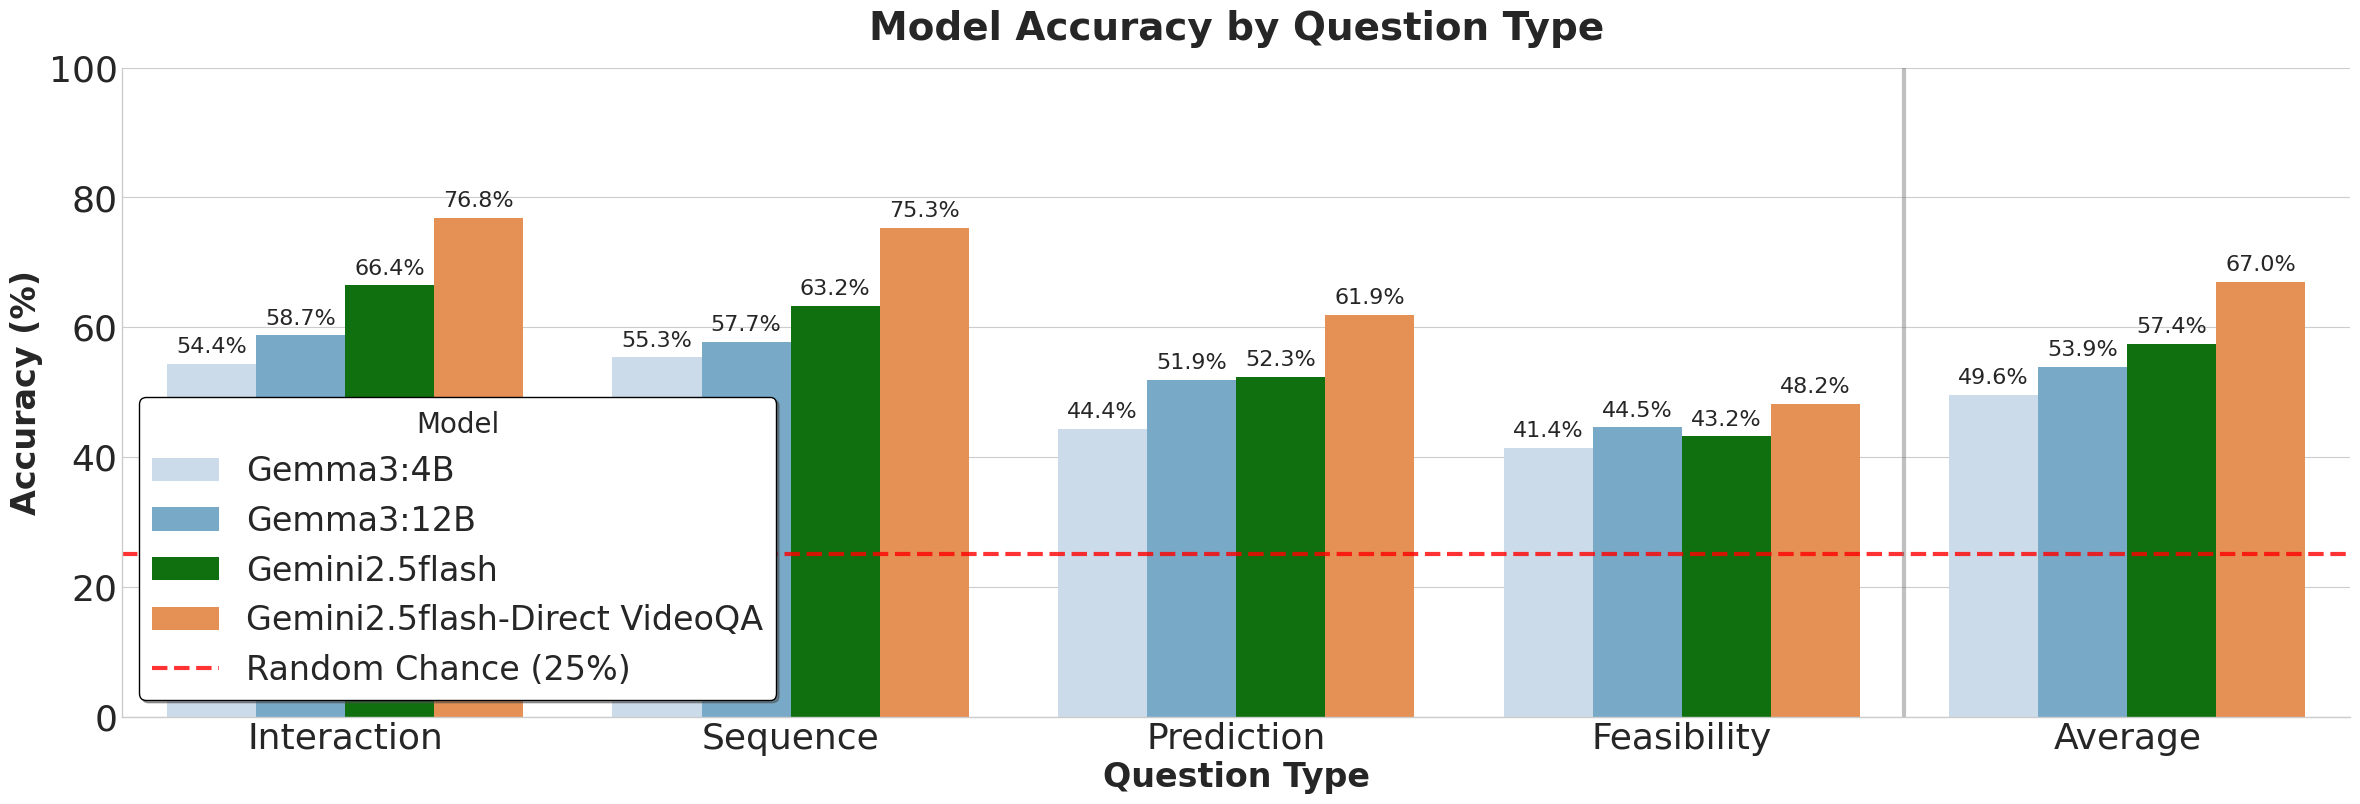

In [24]:
# Extract accuracy data with model size for ordering
data = []
model_sizes = {}

# Iterate through the list of Gemini models
for model_data in model_preds['Gemini']:
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_key = model_data['model_name']
        model_sizes[model_key] = model_data['model_size']
        
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                data.append({
                    'Model': model_key,
                    'Question_Type': question_type,
                    'Accuracy': model_data['accuracy'][question_type] * 100, # Convert to percentage
                    'Model_Size': model_data['model_size']
                })

# Calculate average accuracy for each model across all question types
average_data = []
for model_data in model_preds['Gemini']:
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_key = model_data['model_name']
        accuracies = []
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']:
            if question_type in model_data['accuracy']:
                accuracies.append(model_data['accuracy'][question_type] * 100)
        if accuracies:
            average_data.append({
                'Model': model_key,
                'Question_Type': 'Average',
                'Accuracy': model_data['accuracy'][question_type] * 100,
                'Model_Size': model_data['model_size']
            })

# Combine original data with average data
all_data = data + average_data
df = pd.DataFrame(all_data)

# Sort models by size (since we only have Gemini models now)
def model_sort_key(model_name):
    return model_sizes[model_name]

sorted_models = sorted(model_sizes.keys(), key=model_sort_key)
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create custom color palette for Gemini models
# Separate VideoQA models from non-VideoQA models
vqa_models = [model for model in sorted_models if 'VideoQA' in model]
non_vqa_models = [model for model in sorted_models if 'VideoQA' not in model]

# Use 'Oranges' colormap for VideoQA models, 'Blues' for non-VideoQA models
vqa_colors = sns.color_palette('Oranges', n_colors=len(vqa_models)) if vqa_models else []
non_vqa_colors = sns.color_palette('Blues', n_colors=len(non_vqa_models)) if non_vqa_models else []

# Create a dictionary mapping model names to colors
color_dict = {}
for i, model in enumerate(vqa_models):
    color_dict[model] = vqa_colors[i]
for i, model in enumerate(non_vqa_models):
    color_dict[model] = non_vqa_colors[i]

color_dict['Gemini2.5flash'] = 'Green'
color_dict['Gemma3:4B SGG - Gemma3:4B Graph QA'] = 'Purple'
# Create palette in the order of sorted_models
custom_palette = [color_dict[model] for model in sorted_models]

# Create grouped bar plot with Average
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots() # figsize=(18,6))
sns.barplot(data=df, x='Question_Type', y='Accuracy', hue='Model',
            palette=custom_palette, ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average'])

# Add random chance baseline (25%)
ax.axhline(y=25, color='red', linestyle='--',  alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=16,
                    xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average
ax.axvline(x=3.5, color='gray', linestyle='-', alpha=0.5)

# Styling
ax.set_xlabel('Question Type',)
ax.set_ylabel('Accuracy (%)',)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend
handles, labels = ax.get_legend_handles_labels()
legend = plt.legend(handles, labels, title='Model', loc='lower left',
                   frameon=True, fancybox=True, shadow=True, 
                   facecolor='white', edgecolor='black', framealpha=1)

plt.tight_layout()
plt.savefig('Gemini_comparison_sgg_directVQA_wout_Title.svg', format='svg', dpi=300, bbox_inches='tight')
ax.set_title('Model Accuracy by Question Type', fontweight='bold', pad=20)
plt.savefig('Gemini_comparison_sgg_directVQA.svg', format='svg', dpi=300, bbox_inches='tight')

plt.show()


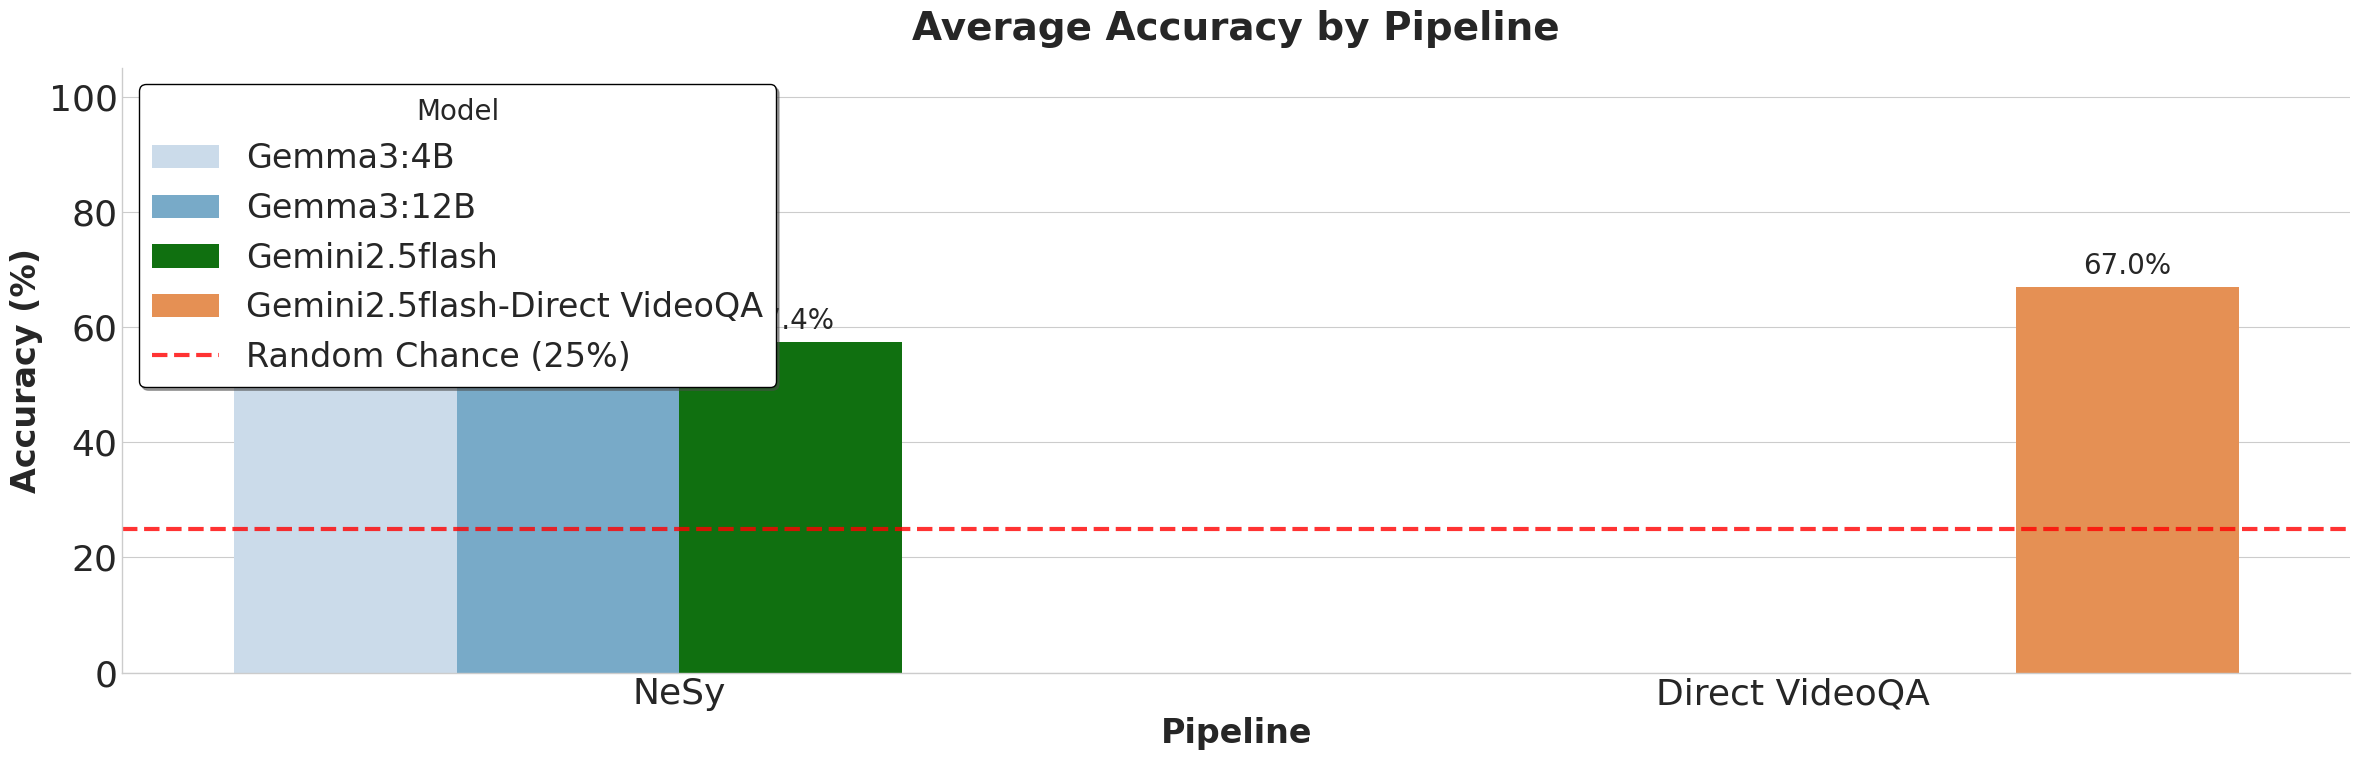

In [25]:
# --- Build/ensure "Average only" dataframe (df_avg) as before ---
# df_avg must have columns: Model, Accuracy (in %), and (we'll add) Group

df_avg = df[df['Question_Type'] == 'Average'].copy()

# Group: Direct VideoQA vs NeSy (based on model name containing 'VideoQA')
df_avg['Group'] = df_avg['Model'].apply(lambda m: 'Direct VideoQA' if 'VideoQA' in m else 'NeSy')

# Keep your size-based ordering if you like (optional)
sorted_models = sorted(model_sizes.keys(), key=lambda m: model_sizes[m])
df_avg['Model'] = pd.Categorical(df_avg['Model'], categories=sorted_models, ordered=True)

# --- Palette base from your existing color_dict (fallback handled in the plot function anyway) ---
PALETTE_BASE = dict(color_dict)  # reuse your colors per model

# Accuracy metric label (used in the title)
ACCURACY_METRIC = 'accuracy'

import matplotlib.pyplot as plt
import seaborn as sns

def plot_ne_sy_vs_vqa(df_all, nesy_models_to_include, outfile_suffix):
    # Subset: requested NeSy models + ALL Direct VideoQA models
    vqa_models_present = df_all.loc[df_all['Group'] == 'Direct VideoQA', 'Model'].unique().tolist()
    df_subset = pd.concat([
        df_all[(df_all['Group'] == 'NeSy') & (df_all['Model'].isin(nesy_models_to_include))],
        df_all[(df_all['Group'] == 'Direct VideoQA')]
    ], ignore_index=True)

    if df_subset.empty:
        print("No data available for the requested selection.")
        return

    # Hue order: NeSy first (in requested order), then all Direct VideoQA models (sorted)
    hue_order = [m for m in nesy_models_to_include if m in df_subset['Model'].unique()]
    hue_order += [m for m in sorted(vqa_models_present) if m in df_subset['Model'].unique()]

    # Palette: pick from the base only for present hues
    palette = {m: PALETTE_BASE.get(m, 'gray') for m in hue_order}

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots()

    sns.barplot(
        data=df_subset,
        x='Group', y='Accuracy',
        hue='Model',
        order=['NeSy', 'Direct VideoQA'] if 'Direct VideoQA' in df_subset['Group'].unique() else ['NeSy'],
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        dodge=True
    )

    # Labels on bars
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}%',
                        (p.get_x() + p.get_width()/2., h),
                        ha='center', va='bottom',
                        xytext=(0, 5), textcoords='offset points')

    # Baseline
    ax.axhline(y=25, color='red', linestyle='--', alpha=0.8, label='Random Chance (25%)')

    # Titles & axes
    title = 'Average Accuracy by Pipeline' if ACCURACY_METRIC == 'accuracy' \
            else 'Average Accuracy by Pipeline - Only answered questions'
    ax.set_title(title, fontweight='bold', pad=20)
    ax.set_xlabel('Pipeline')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', length=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend: ensure baseline last if captured
    handles, labels = ax.get_legend_handles_labels()
    if 'Random Chance (25%)' in labels:
        rc_idx = labels.index('Random Chance (25%)')
        handles.append(handles.pop(rc_idx))
        labels.append(labels.pop(rc_idx))

    ax.legend(handles, labels, title='Model', loc='upper left',
              frameon=True, fancybox=True, shadow=True,
              facecolor='white', edgecolor='black', framealpha=1)

    plt.tight_layout()
    plt.savefig(f'pipeline_comparison_{ACCURACY_METRIC}_{outfile_suffix}.svg',
                format='svg', dpi=300, bbox_inches='tight')
    plt.show()

# --- Example call: include all NeSy (non-VideoQA) models present, keep all Direct VideoQA automatically ---
nesy_models_present = df_avg.loc[df_avg['Group'] == 'NeSy', 'Model'].tolist()
plot_ne_sy_vs_vqa(df_avg, nesy_models_present, outfile_suffix='multiple_models_avg')


In [26]:
temp = model_preds['NeSy'][0]
temp['model_name'] = 'Gemma3:4B SGG - Gemma3:4B Graph QA'
model_preds['Gemini'].insert(0, temp)

# ------------

temp = model_preds['Direct VideoQA'][0]
temp['model_name'] = 'Gemma3:4B-Direct VideoQA'
model_preds['Gemini'].insert(1, temp)


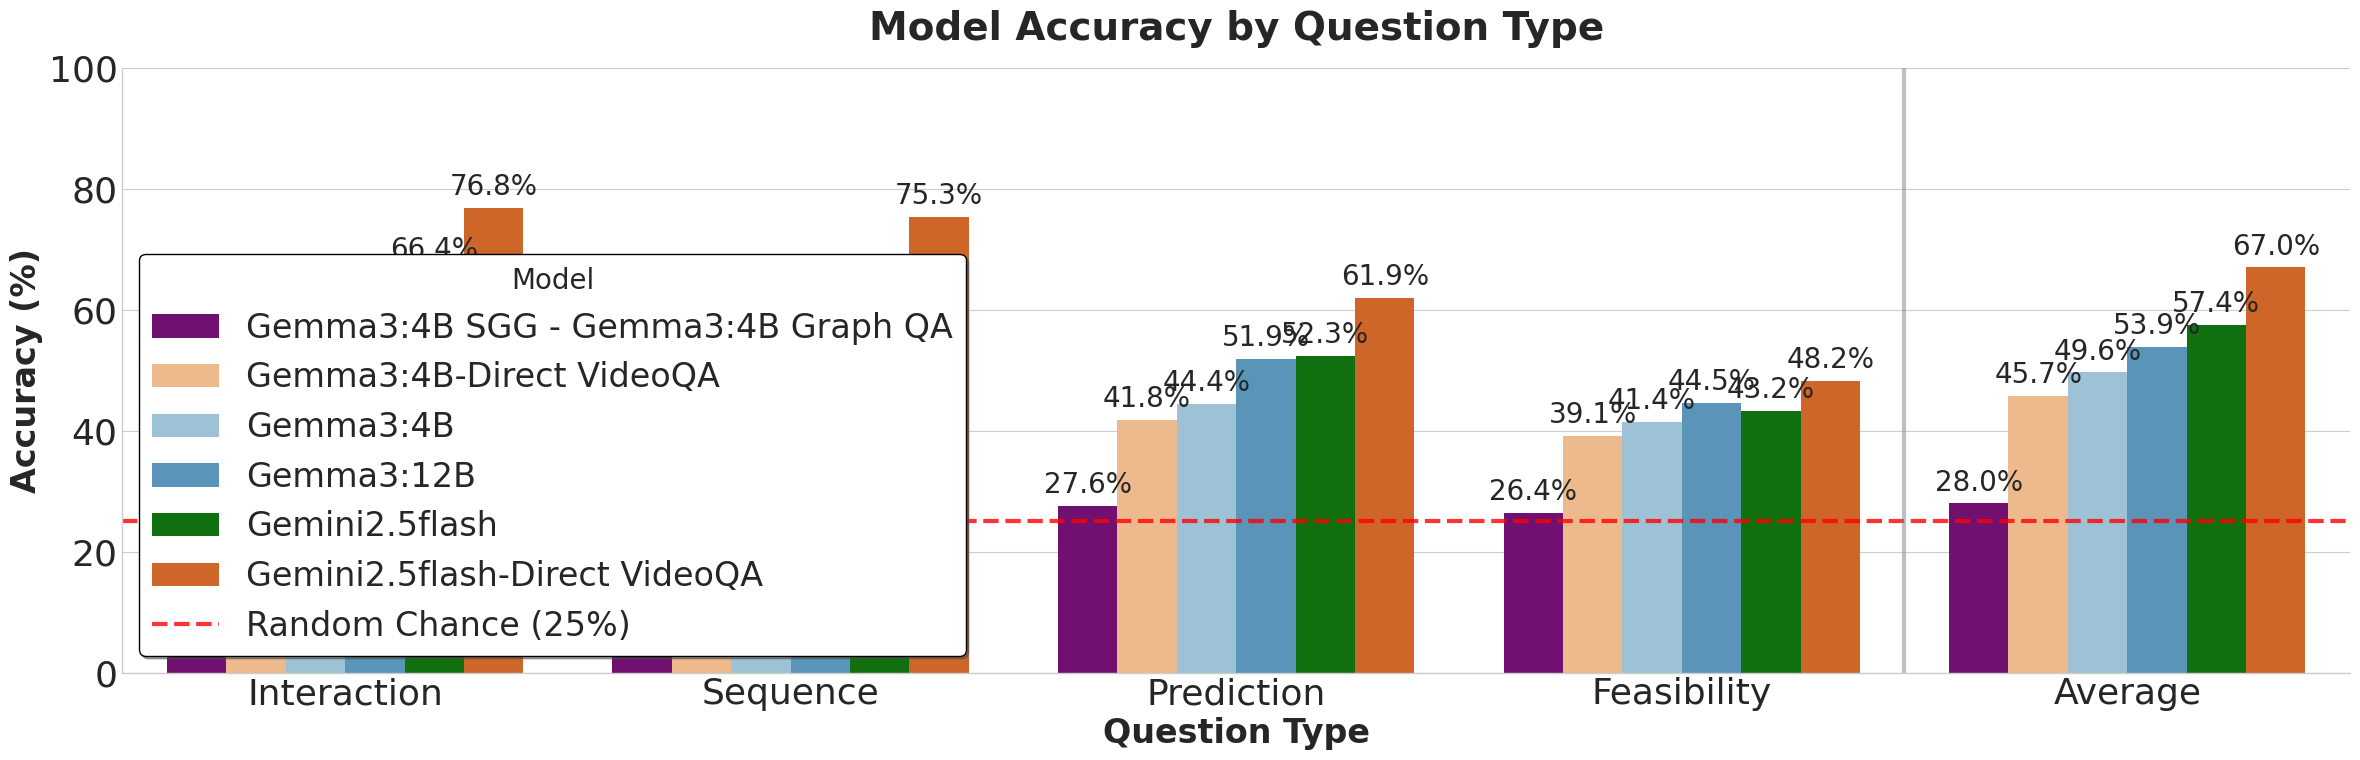

In [27]:
# Extract accuracy data with model size for ordering
data = []
model_sizes = {}

# Iterate through the list of Gemini models
for model_data in model_preds['Gemini']:
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_key = model_data['model_name']
        model_sizes[model_key] = model_data['model_size']
        
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                data.append({
                    'Model': model_key,
                    'Question_Type': question_type,
                    'Accuracy': model_data['accuracy'][question_type] * 100, # Convert to percentage
                    'Model_Size': model_data['model_size']
                })

# Calculate average accuracy for each model across all question types
average_data = []
for model_data in model_preds['Gemini']:
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_key = model_data['model_name']
        accuracies = []
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']:
            if question_type in model_data['accuracy']:
                accuracies.append(model_data['accuracy'][question_type] * 100)
        if accuracies:
            average_data.append({
                'Model': model_key,
                'Question_Type': 'Average',
                'Accuracy': model_data['accuracy'][question_type] * 100,
                'Model_Size': model_data['model_size']
            })

# Combine original data with average data
all_data = data + average_data
df = pd.DataFrame(all_data)

# Sort models by size (since we only have Gemini models now)
def model_sort_key(model_name):
    return model_sizes[model_name]

sorted_models = sorted(model_sizes.keys(), key=model_sort_key)
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create custom color palette for Gemini models
# Separate VideoQA models from non-VideoQA models
vqa_models = [model for model in sorted_models if 'VideoQA' in model]
non_vqa_models = [model for model in sorted_models if 'VideoQA' not in model]

# Use 'Oranges' colormap for VideoQA models, 'Blues' for non-VideoQA models
vqa_colors = sns.color_palette('Oranges', n_colors=len(vqa_models)) if vqa_models else []
non_vqa_colors = sns.color_palette('Blues', n_colors=len(non_vqa_models)) if non_vqa_models else []

# Create a dictionary mapping model names to colors
color_dict = {}
for i, model in enumerate(vqa_models):
    color_dict[model] = vqa_colors[i]
for i, model in enumerate(non_vqa_models):
    color_dict[model] = non_vqa_colors[i]

color_dict['Gemini2.5flash'] = 'Green'
color_dict['Gemma3:4B SGG - Gemma3:4B Graph QA'] = 'Purple'
# Create palette in the order of sorted_models
custom_palette = [color_dict[model] for model in sorted_models]

# Create grouped bar plot with Average
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots() # figsize=(18,6))
sns.barplot(data=df, x='Question_Type', y='Accuracy', hue='Model',
            palette=custom_palette, ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average'])

# Add random chance baseline (25%)
ax.axhline(y=25, color='red', linestyle='--',  alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average
ax.axvline(x=3.5, color='gray', linestyle='-', alpha=0.5)

# Styling
ax.set_title('Model Accuracy by Question Type', fontweight='bold', pad=20)
ax.set_xlabel('Question Type',)
ax.set_ylabel('Accuracy (%)',)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend
handles, labels = ax.get_legend_handles_labels()
legend = plt.legend(handles, labels, title='Model', loc='lower left',
                   frameon=True, fancybox=True, shadow=True, 
                   facecolor='white', edgecolor='black', framealpha=1)

plt.tight_layout()
plt.savefig('experiment.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


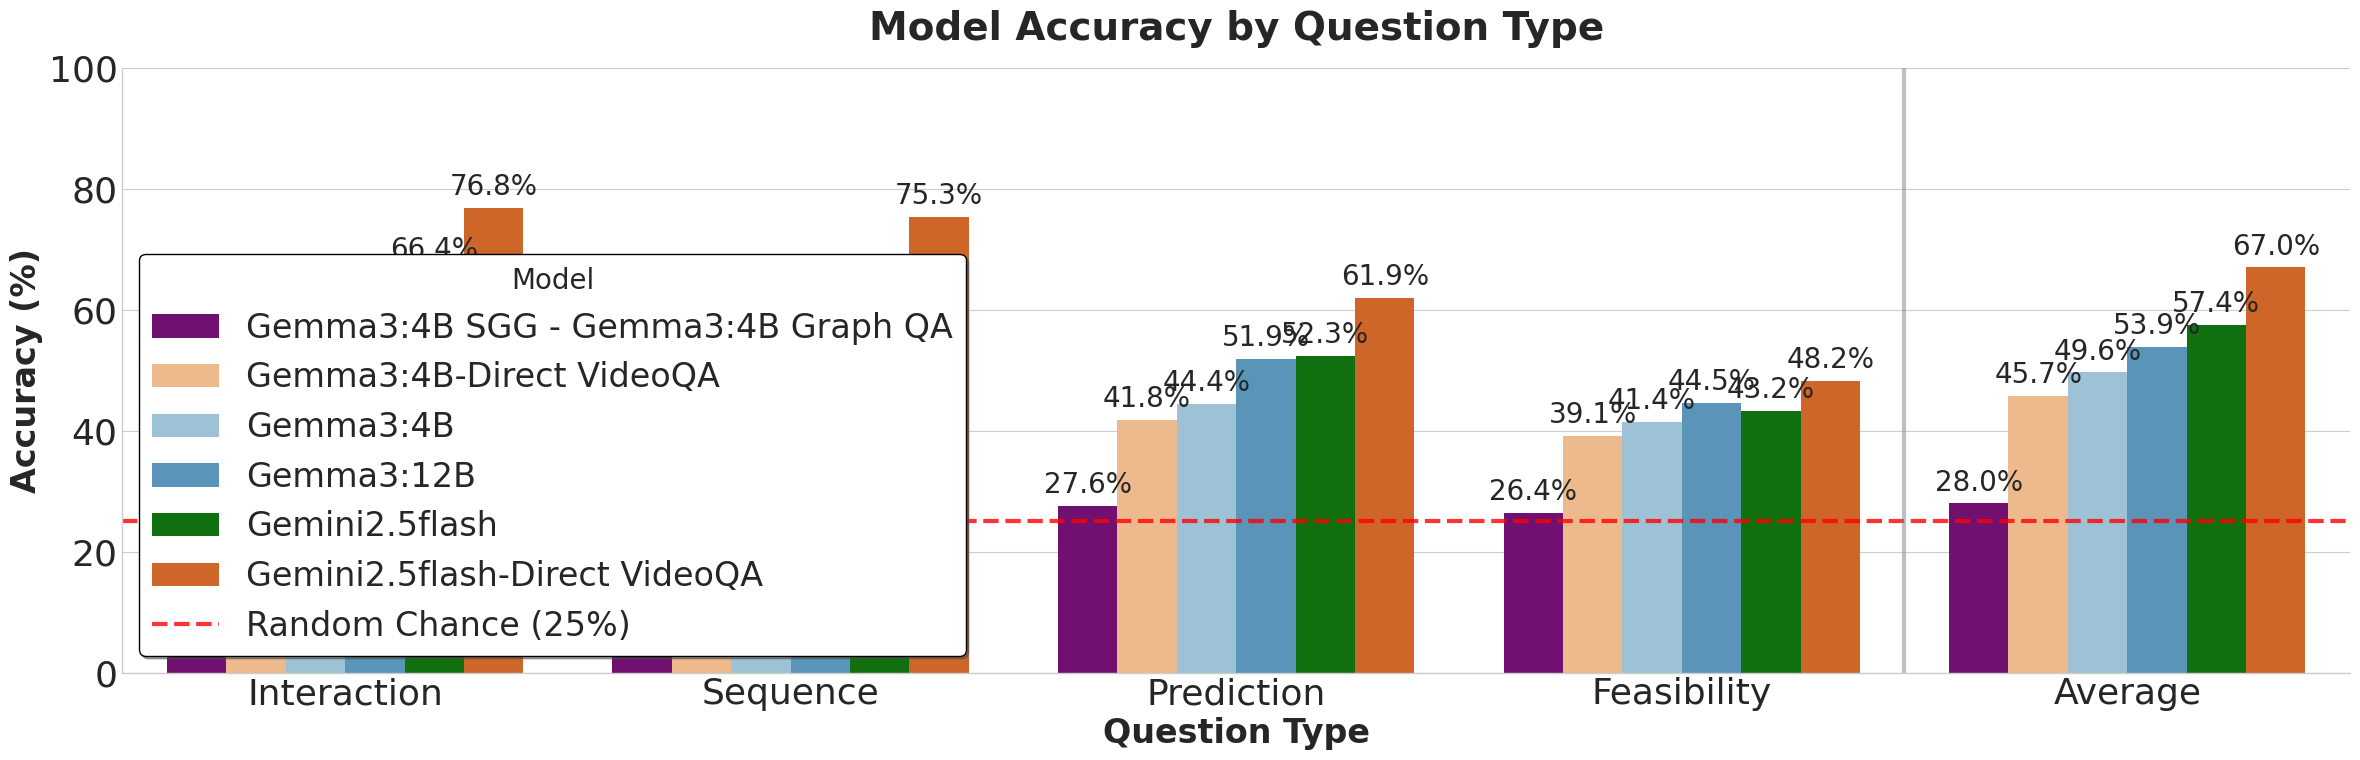

In [28]:
# Extract accuracy data with model size for ordering
data = []
model_sizes = {}

# Iterate through the list of Gemini models
for model_data in model_preds['Gemini']:
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_key = model_data['model_name']
        model_sizes[model_key] = model_data['model_size']
        
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                data.append({
                    'Model': model_key,
                    'Question_Type': question_type,
                    'Accuracy': model_data['accuracy'][question_type] * 100, # Convert to percentage
                    'Model_Size': model_data['model_size']
                })

# Calculate average accuracy for each model across all question types
average_data = []
for model_data in model_preds['Gemini']:
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_key = model_data['model_name']
        accuracies = []
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']:
            if question_type in model_data['accuracy']:
                accuracies.append(model_data['accuracy'][question_type] * 100)
        if accuracies:
            average_data.append({
                'Model': model_key,
                'Question_Type': 'Average',
                'Accuracy': model_data['accuracy'][question_type] * 100,
                'Model_Size': model_data['model_size']
            })

# Combine original data with average data
all_data = data + average_data
df = pd.DataFrame(all_data)

# Sort models by size (since we only have Gemini models now)
def model_sort_key(model_name):
    return model_sizes[model_name]

sorted_models = sorted(model_sizes.keys(), key=model_sort_key)
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create custom color palette for Gemini models
# Separate VideoQA models from non-VideoQA models
vqa_models = [model for model in sorted_models if 'VideoQA' in model]
non_vqa_models = [model for model in sorted_models if 'VideoQA' not in model]

# Use 'Oranges' colormap for VideoQA models, 'Blues' for non-VideoQA models
vqa_colors = sns.color_palette('Oranges', n_colors=len(vqa_models)) if vqa_models else []
non_vqa_colors = sns.color_palette('Blues', n_colors=len(non_vqa_models)) if non_vqa_models else []

# Create a dictionary mapping model names to colors
color_dict = {}
for i, model in enumerate(vqa_models):
    color_dict[model] = vqa_colors[i]
for i, model in enumerate(non_vqa_models):
    color_dict[model] = non_vqa_colors[i]

color_dict['Gemini2.5flash'] = 'Green'
color_dict['Gemma3:4B SGG - Gemma3:4B Graph QA'] = 'Purple'
# Create palette in the order of sorted_models
custom_palette = [color_dict[model] for model in sorted_models]

# Create grouped bar plot with Average
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots() # figsize=(18,6))
sns.barplot(data=df, x='Question_Type', y='Accuracy', hue='Model',
            palette=custom_palette, ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average'])

# Add random chance baseline (25%)
ax.axhline(y=25, color='red', linestyle='--',  alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average
ax.axvline(x=3.5, color='gray', linestyle='-', alpha=0.5)

# Styling
ax.set_title('Model Accuracy by Question Type', fontweight='bold', pad=20)
ax.set_xlabel('Question Type',)
ax.set_ylabel('Accuracy (%)',)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend
handles, labels = ax.get_legend_handles_labels()
legend = plt.legend(handles, labels, title='Model', loc='lower left',
                   frameon=True, fancybox=True, shadow=True, 
                   facecolor='white', edgecolor='black', framealpha=1)

plt.tight_layout()
plt.savefig('experiment.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
[i['model_name'] for i in model_preds['Gemini']]


['Gemma3:4B SGG - Gemma3:4B Graph QA',
 'Gemma3:4B-Direct VideoQA',
 'Gemma3:4B',
 'Gemma3:12B',
 'Gemini2.5flash',
 'Gemini2.5flash-Direct VideoQA']

In [ ]:
model_preds['Gemini'][0]['support_ratio']


{'Interaction': 0.6577181208053692,
 'Sequence': 0.5154639175257731,
 'Prediction': 0.7154811715481172,
 'Feasibility': 0.6318181818181818,
 'Average': 0.6259541984732825}

In [ ]:
model_preds['Gemini'][2]['support_ratio']


{'Interaction': 0.9664429530201343,
 'Sequence': 0.9312714776632303,
 'Prediction': 0.9665271966527197,
 'Feasibility': 0.9318181818181818,
 'Average': 0.9494274809160306}

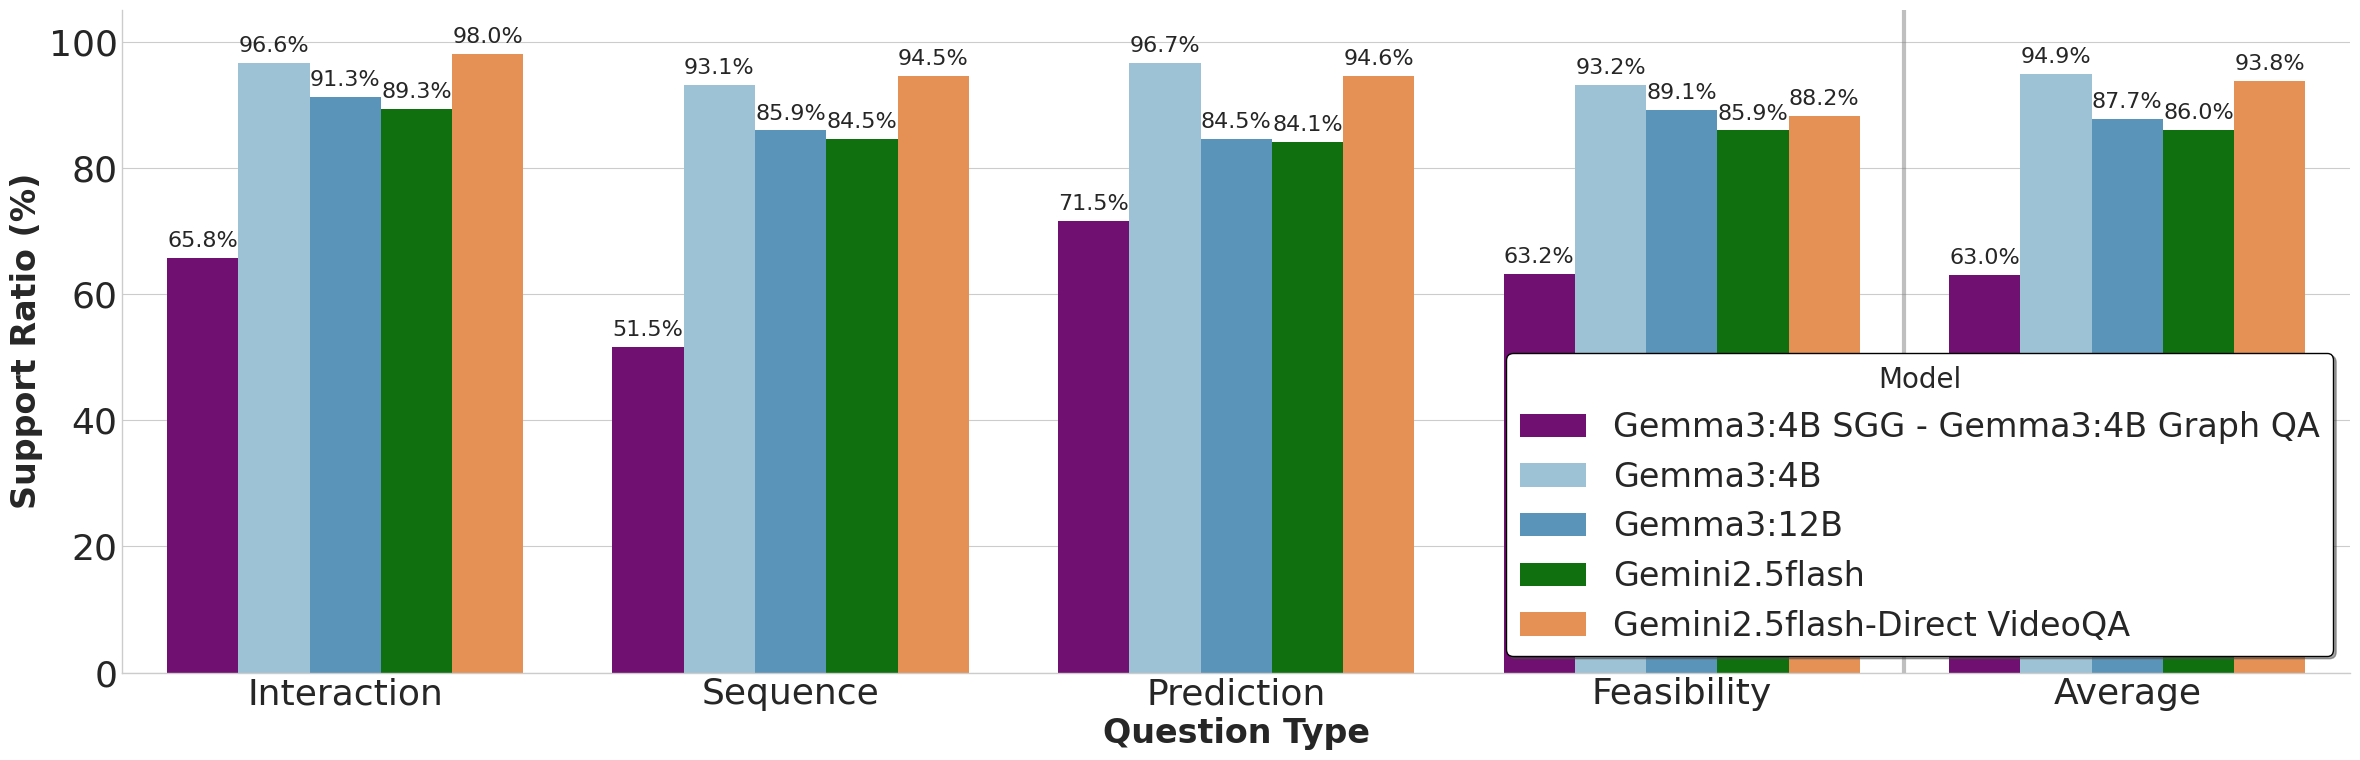

In [33]:
# Extract support ratio data with model size for ordering
data = []
model_sizes = {}

# Iterate through the list of Gemini models
for model_data in model_preds['Gemini']:
    if isinstance(model_data, dict) and 'support_ratio' in model_data:
        model_key = model_data['model_name']
        model_sizes[model_key] = model_data['model_size']
        
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['support_ratio']:
                data.append({
                    'Model': model_key,
                    'Question_Type': question_type,
                    'Support_Ratio': model_data['support_ratio'][question_type] * 100, # Convert to percentage
                    'Model_Size': model_data['model_size']
                })

# Calculate average support ratio for each model across all question types
average_data = []
for model_data in model_preds['Gemini']:
    if isinstance(model_data, dict) and 'support_ratio' in model_data:
        model_key = model_data['model_name']
        support_ratios = []
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['support_ratio']:
                support_ratios.append(model_data['support_ratio'][question_type] * 100)
        if support_ratios:
            # Calculate average support ratio
            avg_support_ratio = sum(support_ratios) / len(support_ratios)
            average_data.append({
                'Model': model_key,
                'Question_Type': 'Average',
                'Support_Ratio': avg_support_ratio,
                'Model_Size': model_data['model_size']
            })

# Combine original data with average data
all_data = data + average_data
df = pd.DataFrame(all_data)

# Sort models by size (since we only have Gemini models now)
def model_sort_key(model_name):
    return model_sizes[model_name]

sorted_models = sorted(model_sizes.keys(), key=model_sort_key)
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create custom color palette for Gemini models
# Separate VideoQA models from non-VideoQA models
vqa_models = [model for model in sorted_models if 'VideoQA' in model]
non_vqa_models = [model for model in sorted_models if 'VideoQA' not in model]

# Use 'Oranges' colormap for VideoQA models, 'Blues' for non-VideoQA models
vqa_colors = sns.color_palette('Oranges', n_colors=len(vqa_models)) if vqa_models else []
non_vqa_colors = sns.color_palette('Blues', n_colors=len(non_vqa_models)) if non_vqa_models else []

# Create a dictionary mapping model names to colors
color_dict = {}
for i, model in enumerate(vqa_models):
    color_dict[model] = vqa_colors[i]
for i, model in enumerate(non_vqa_models):
    color_dict[model] = non_vqa_colors[i]

color_dict['Gemini2.5flash'] = 'Green'
color_dict['Gemma3:4B SGG - Gemma3:4B Graph QA'] = 'Purple'
# Create palette in the order of sorted_models
custom_palette = [color_dict[model] for model in sorted_models]

# Create grouped bar plot with Average
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots()
sns.barplot(data=df, x='Question_Type', y='Support_Ratio', hue='Model',
            palette=custom_palette, ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average'])

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=16,
                    xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average
ax.axvline(x=3.5, color='gray', linestyle='-',  alpha=0.5)

# Styling

ax.set_xlabel('Question Type',)
ax.set_ylabel('Support Ratio (%)',)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend with white background frame

handles, labels = ax.get_legend_handles_labels()
legend = plt.legend(handles, labels, title='Model', loc='lower right',
                   frameon=True, fancybox=True, shadow=True, 
                   facecolor='white', edgecolor='black', framealpha=1)

#ax.set_title('Percentage of Answered Questions', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('endtoend_gemini_ans_perc.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
model_preds['Direct VideoQA'][0]


{'model_name': 'Gemma3:4B-Direct VideoQA',
 'predictions_df':                                                           chat_history  \
 id                                                                       
 Feasibility_T5_102   [{'role': 'user', 'content': 'You are an intel...   
 Feasibility_T2_860   [{'role': 'user', 'content': 'You are an intel...   
 Feasibility_T2_556   [{'role': 'user', 'content': 'You are an intel...   
 Prediction_T1_2539   [{'role': 'user', 'content': 'You are an intel...   
 Prediction_T4_1253   [{'role': 'user', 'content': 'You are an intel...   
 ...                                                                ...   
 Interaction_T1_8913  [{'role': 'user', 'content': 'You are an intel...   
 Interaction_T1_8967  [{'role': 'user', 'content': 'You are an intel...   
 Interaction_T2_1847  [{'role': 'user', 'content': 'You are an intel...   
 Interaction_T2_3423  [{'role': 'user', 'content': 'You are an intel...   
 Interaction_T4_4181  [{'role': 'user',

/tmp/ipykernel_300786/2768932482.py:190: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(question_type_order)


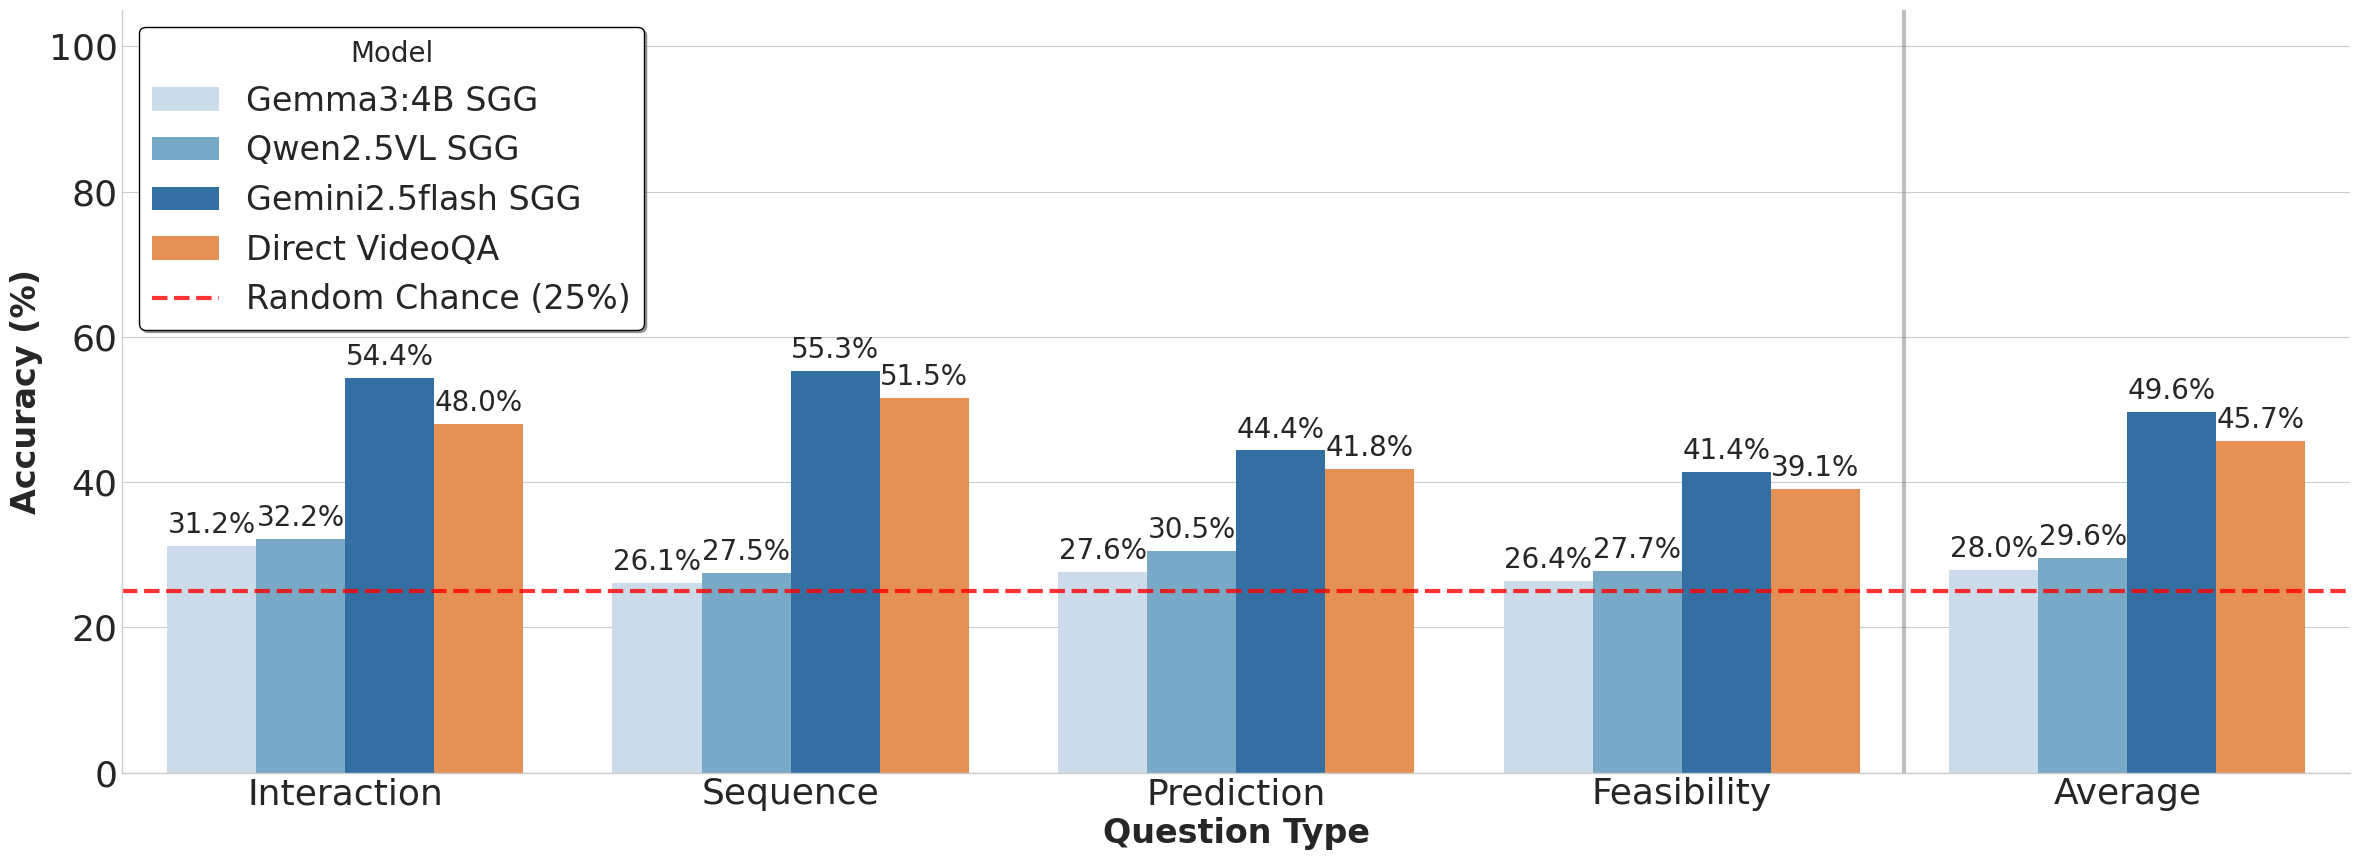

In [155]:
# HYPERPARAMETER: Choose which accuracy metric to plot
from collections import OrderedDict

ACCURACY_METRIC = "accuracy"  # Options: "accuracy", "accuracy_contains_answer"

setting_mapping = OrderedDict({
    "NeSy": "Gemma3:4B SGG",
    "NeSy2": "Qwen2.5VL SGG",
    "Gemini": "Gemini2.5flash SGG",
    "Direct VideoQA": "Direct VideoQA",
    })

# Extract accuracy data for the new list-based structure with question type breakdown
data = []
model_sizes = {}
support_info = {}  # Store support information for each model

for approach_name, models_list in model_preds.items():
    for model_data in models_list:
        if (
            isinstance(model_data, dict)
            and model_data['model_name'].startswith('Gemma3:4B')
            and 'accuracy' in model_data
            ):
            
            model_name = model_data['model_name']
            model_size = model_data.get('model_size', 0)
            # Use original key name directly
            model_display_name = approach_name  # Use the original key name
            
            # Store model size for sorting
            model_sizes[model_display_name] = model_size
            
            # Check if the selected accuracy metric exists
            if ACCURACY_METRIC not in model_data:
                print(f"Warning: {ACCURACY_METRIC} not found in {model_display_name}, skipping...")
                continue
            
            eval_df = model_data.get('eval_df', None)
            # Calculate support based on accuracy metric
            if ACCURACY_METRIC == "accuracy":
                support = eval_df.shape[0]  # Assuming eval_df.shape[0] is stored
            elif ACCURACY_METRIC == "accuracy_contains_answer":
                support = eval_df['contains_answer'].sum()  # Assuming eval_df['contains_answer'].sum() is stored
                eval_df = eval_df[eval_df['contains_answer']]
            else:
                support = model_data.get('eval_df', None).shape[0]  # Default fallback
            
            # Store support info
            support_info[model_display_name] = support
            
            # Extract accuracy data for each question type from the selected metric
            accuracy_data = model_data[ACCURACY_METRIC]
            
            # Calculate question counts grouped by question type
            question_type_counts = {}
            if eval_df is not None:
                # Group by question_type and sum contains_answer for each group
                question_type_counts = eval_df.groupby(by=lambda x: str(x.split('_')[0]))['question'].count().to_dict()
                # Add total count for Average
                question_type_counts['Average'] = support
            
            # Handle both dictionary and single value formats
            if isinstance(accuracy_data, dict):
                # If it's a dictionary with question types
                for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']:
                    if question_type in accuracy_data:
                        # Get question count for this specific question type
                        question_count = question_type_counts.get(question_type, None)
                        
                        data.append({
                            'Model': model_display_name,
                            'Question_Type': question_type,
                            'Accuracy': accuracy_data[question_type] * 100,  # Convert to percentage
                            'Model_Size': model_size,
                            'Approach': approach_name,
                            'Base_Model': model_name,
                            'Support': support,
                            'Question_Count': question_count
                        })
            else:
                # If it's a single value, treat as overall accuracy
                question_count = question_type_counts.get('Average', support) if question_type_counts else support
                data.append({
                    'Model': model_display_name,
                    'Question_Type': 'Overall',
                    'Accuracy': accuracy_data * 100,  # Convert to percentage
                    'Model_Size': model_size,
                    'Approach': approach_name,
                    'Base_Model': model_name,
                    'Support': support,
                    'Question_Count': question_count
                })

# Create DataFrame
df = pd.DataFrame(data)

# Order models according to the OrderedDict
model_order = list(setting_mapping.keys())
# Filter to only include models that exist in the data
available_models = df['Model'].unique()
sorted_models = [model for model in model_order if model in available_models]

df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create custom color palette based on model type
# Direct VideoQA models get Orange colors, SGG models get Blue colors
vqa_models = [model for model in sorted_models if 'VideoQA' in setting_mapping.get(model, '')]
sgg_models = [model for model in sorted_models if 'SGG' in setting_mapping.get(model, '')]

# Generate colors
vqa_colors = sns.color_palette('Oranges', n_colors=len(vqa_models)) if vqa_models else []
sgg_colors = sns.color_palette('Blues', n_colors=len(sgg_models)) if sgg_models else []

# Create color mapping
color_dict = {}
for i, model in enumerate(vqa_models):
    color_dict[model] = vqa_colors[i]
for i, model in enumerate(sgg_models):
    color_dict[model] = sgg_colors[i]

# Create palette in the order of sorted_models
custom_palette = [color_dict[model] for model in sorted_models]

# Create the main plot with all question types
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(24, 9))

# Define question type order based on data structure
available_question_types = df['Question_Type'].unique()
if 'Average' in available_question_types:
    # If we have question type breakdown
    question_type_order = ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']
    question_type_order = [qt for qt in question_type_order if qt in available_question_types]
else:
    # If we have overall accuracy only
    question_type_order = list(available_question_types)

# Filter to available question types for the primary plot
main_df = df[df['Question_Type'].isin(question_type_order)]

# Create barplot with custom colors
sns.barplot(data=main_df, x='Question_Type', y='Accuracy', hue='Model',
            palette=custom_palette, ax=ax, order=question_type_order)

# Add random chance baseline (25% for 4-choice questions)
ax.axhline(y=25, color='red', linestyle='--',  alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars with question counts
for p in ax.patches:
    if p.get_height() > 0:
        # Find the corresponding data point to get question count
        bar_index = ax.patches.index(p)
        # Calculate which question type and model this bar corresponds to
        n_models = len(sorted_models)
        question_type_idx = bar_index % len(question_type_order)
        model_idx = bar_index // len(question_type_order)
        
        if question_type_idx < len(question_type_order) and model_idx < len(sorted_models):
            current_question_type = question_type_order[question_type_idx]
            current_model = sorted_models[model_idx]
            
            # Find the question count for this specific combination
            matching_rows = main_df[
                (main_df['Question_Type'] == current_question_type) & 
                (main_df['Model'] == current_model)
            ]
            
            if not matching_rows.empty:
                question_count = matching_rows.iloc[0]['Question_Count']
                ax_label = f'{p.get_height():.1f}%'
                if ACCURACY_METRIC == 'accuracy_contains_answer':
                    ax_label += f'\n(n={question_count})'
                ax.annotate(ax_label,
                           (p.get_x() + p.get_width()/2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 5), textcoords='offset points')
            else:
                ax.annotate(f'{p.get_height():.1f}%',
                           (p.get_x() + p.get_width()/2., p.get_height()),
                           ha='center', va='bottom',
                           xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average (only if Average exists)
if 'Average' in available_question_types and len(question_type_order) > 1:
    avg_position = question_type_order.index('Average') - 0.5
    ax.axvline(x=avg_position, color='gray', linestyle='-',  alpha=0.5)

# Create x-labels (keeping original question type names)
ax.set_xticklabels(question_type_order)

# Styling
metric_display_name = ACCURACY_METRIC.replace('_', ' ').title()
if ACCURACY_METRIC == 'accuracy':
    title = 'Pipeline Comparison: SGG vs Direct VideoQA Accuracy by Question Type'
else:
    title = 'Pipeline Comparison: SGG vs Direct VideoQA Accuracy by Question Type - Only answered questions'


ax.set_xlabel('Question Type',)
ax.set_ylabel('Accuracy (%)',)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend to show the mapped display names and conditionally include support information
handles, labels = ax.get_legend_handles_labels()
# Create labels with mapped names and conditionally add support information
clean_labels = []
for label in labels:
    if label != 'Random Chance (25%)':
        # Use the mapped display name
        display_name = setting_mapping.get(label, label)
        
        # Only add support information for accuracy_contains_answer metric
        if ACCURACY_METRIC == "accuracy_contains_answer":
            support = support_info.get(label, 'N/A')
            clean_labels.append(f'{display_name} (n={support})')
        else:
            clean_labels.append(display_name)
    else:
        clean_labels.append(label)

# Set legend title based on whether support is shown
# Update legend
handles, labels = ax.get_legend_handles_labels()
legend = plt.legend(handles, clean_labels, title='Model', loc='upper left',
                   frameon=True, fancybox=True, shadow=True, 
                   facecolor='white', edgecolor='black', framealpha=1)

plt.tight_layout()
#ax.set_title(title, fontweight='bold', pad=20)
plt.savefig(f'entoend_gemma4B_differentSGG.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


## Gemma3-4B comparison

In [109]:
# --- CONFIG ---
ACCURACY_METRIC = "accuracy"  # or "accuracy_contains_answer"

# Pretty labels for hue
PRETTY_MODEL_NAME = {
    "NeSy": "Gemma3:4B SGG",
    "NeSy2": "Qwen-2.5-VL:7B SGG",
    "Direct VideoQA": "Direct VideoQA",
    "Gemini": "Gemini-2-5-Flash SGG",  # filtered Gemini entry only
}

def _append_row(rows, group_label, model_label, model_data):
    eval_df = model_data.get('eval_df', None)
    if ACCURACY_METRIC == "accuracy":
        support = eval_df.shape[0]
    elif ACCURACY_METRIC == "accuracy_contains_answer":
        support = eval_df['contains_answer'].sum()
        eval_df = eval_df[eval_df['contains_answer']]
    else:
        support = model_data.get('eval_df', None).shape[0]

    accuracy_data = model_data[ACCURACY_METRIC]

    question_type_counts = {}
    if eval_df is not None:
        question_type_counts = (
            eval_df.groupby(by=lambda x: str(x.split('_')[0]))['question'].count().to_dict()
        )
        question_type_counts['Average'] = support

    if isinstance(accuracy_data, dict):
        if 'Average' in accuracy_data:
            rows.append({
                'Group': group_label,
                'Model': model_label,
                'Accuracy': accuracy_data['Average'] * 100,
                'Support': support,
                'Question_Count': question_type_counts.get('Average', None)
            })
    else:
        rows.append({
            'Group': group_label,
            'Model': model_label,
            'Accuracy': accuracy_data * 100,
            'Support': support,
            'Question_Count': question_type_counts.get('Average', support) if question_type_counts else support
        })

# Build df with NeSy (NeSy, NeSy2), filtered Gemini (model_name == "Gemma3:4B"), and any Direct VideoQA
rows = []
for approach_name, models_list in model_preds.items():
    for model_data in models_list:
        if not (isinstance(model_data, dict) and 'accuracy' in model_data):
            continue

        # Keep only Gemini entry with model_name == "Gemma3:4B"
        if approach_name == "Gemini" and model_data.get('model_name') != "Gemma3:4B":
            continue

        if ACCURACY_METRIC not in model_data:
            print(f"Warning: {ACCURACY_METRIC} not found in {approach_name}, skipping...")
            continue

        # Grouping: NeSy family under "NeSy"; VideoQA under "Direct VideoQA"
        if approach_name in ["NeSy", "NeSy2", "Gemini"]:
            group_label = "NeSy"
        elif "VideoQA" in approach_name:
            group_label = "Direct VideoQA"
        else:
            group_label = approach_name

        model_label = PRETTY_MODEL_NAME.get(approach_name, approach_name)
        _append_row(rows, group_label, model_label, model_data)

df = pd.DataFrame(rows)


In [110]:
# Stable, model-specific palette across all plots
import seaborn as sns

# Desired NeSy order for consistent colors
NESY_CANONICAL = ["Gemma3:4B SGG", "Qwen-2.5-VL:7B SGG", "Gemini-2-5-Flash SGG"]

nesy_all = [m for m in NESY_CANONICAL if m in df.loc[df['Group'] == 'NeSy', 'Model'].unique()]
vqa_all  = sorted(df.loc[df['Group'] == 'Direct VideoQA', 'Model'].unique().tolist())

nesy_colors = sns.color_palette('Blues',  n_colors=max(1, len(nesy_all)))[:len(nesy_all)]
vqa_colors  = sns.color_palette('Oranges', n_colors=max(1, len(vqa_all)))[:len(vqa_all)]

PALETTE_BASE = {}
for m, c in zip(nesy_all, nesy_colors):
    PALETTE_BASE[m] = c
for m, c in zip(vqa_all, vqa_colors):
    PALETTE_BASE[m] = c


In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ne_sy_vs_vqa(df_all, nesy_models_to_include, outfile_suffix):
    # Subset: requested NeSy models + ALL Direct VideoQA models
    vqa_models_present = df_all.loc[df_all['Group'] == 'Direct VideoQA', 'Model'].unique().tolist()
    df_subset = pd.concat([
        df_all[(df_all['Group'] == 'NeSy') & (df_all['Model'].isin(nesy_models_to_include))],
        df_all[(df_all['Group'] == 'Direct VideoQA')]
    ], ignore_index=True)

    if df_subset.empty:
        print("No data available for the requested selection.")
        return

    # Hue order: NeSy first (in requested order), then all Direct VideoQA models (sorted)
    hue_order = [m for m in nesy_models_to_include if m in df_subset['Model'].unique()]
    hue_order += [m for m in sorted(vqa_models_present) if m in df_subset['Model'].unique()]

    # Palette: pick from the stable base only for present hues
    palette = {m: PALETTE_BASE[m] for m in hue_order if m in PALETTE_BASE}

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots()

    sns.barplot(
        data=df_subset,
        x='Group', y='Accuracy',
        hue='Model',
        order=['NeSy', 'Direct VideoQA'] if 'Direct VideoQA' in df_subset['Group'].unique() else ['NeSy'],
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        dodge=True
    )

    # Labels
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom',
                        xytext=(0, 5), textcoords='offset points')

    # Baseline
    ax.axhline(y=25, color='red', linestyle='--', alpha=0.8, label='Random Chance (25%)')

    # Titles & axes
    title = 'Average Accuracy by Pipeline' if ACCURACY_METRIC == 'accuracy' else 'Average Accuracy by Pipeline - Only answered questions'
    ax.set_title(title, fontweight='bold', pad=20)
    ax.set_xlabel('Pipeline')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', length=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend: ensure baseline last if captured
    handles, labels = ax.get_legend_handles_labels()
    if 'Random Chance (25%)' in labels:
        rc_idx = labels.index('Random Chance (25%)')
        handles.append(handles.pop(rc_idx))
        labels.append(labels.pop(rc_idx))

    ax.legend(handles, labels, title='Model', loc='upper left',
              frameon=True, fancybox=True, shadow=True,
              facecolor='white', edgecolor='black', framealpha=1)

    plt.tight_layout()
    plt.savefig(f'pipeline_comparison_{ACCURACY_METRIC}_{outfile_suffix}.svg',
                format='svg', dpi=300, bbox_inches='tight')
    plt.show()


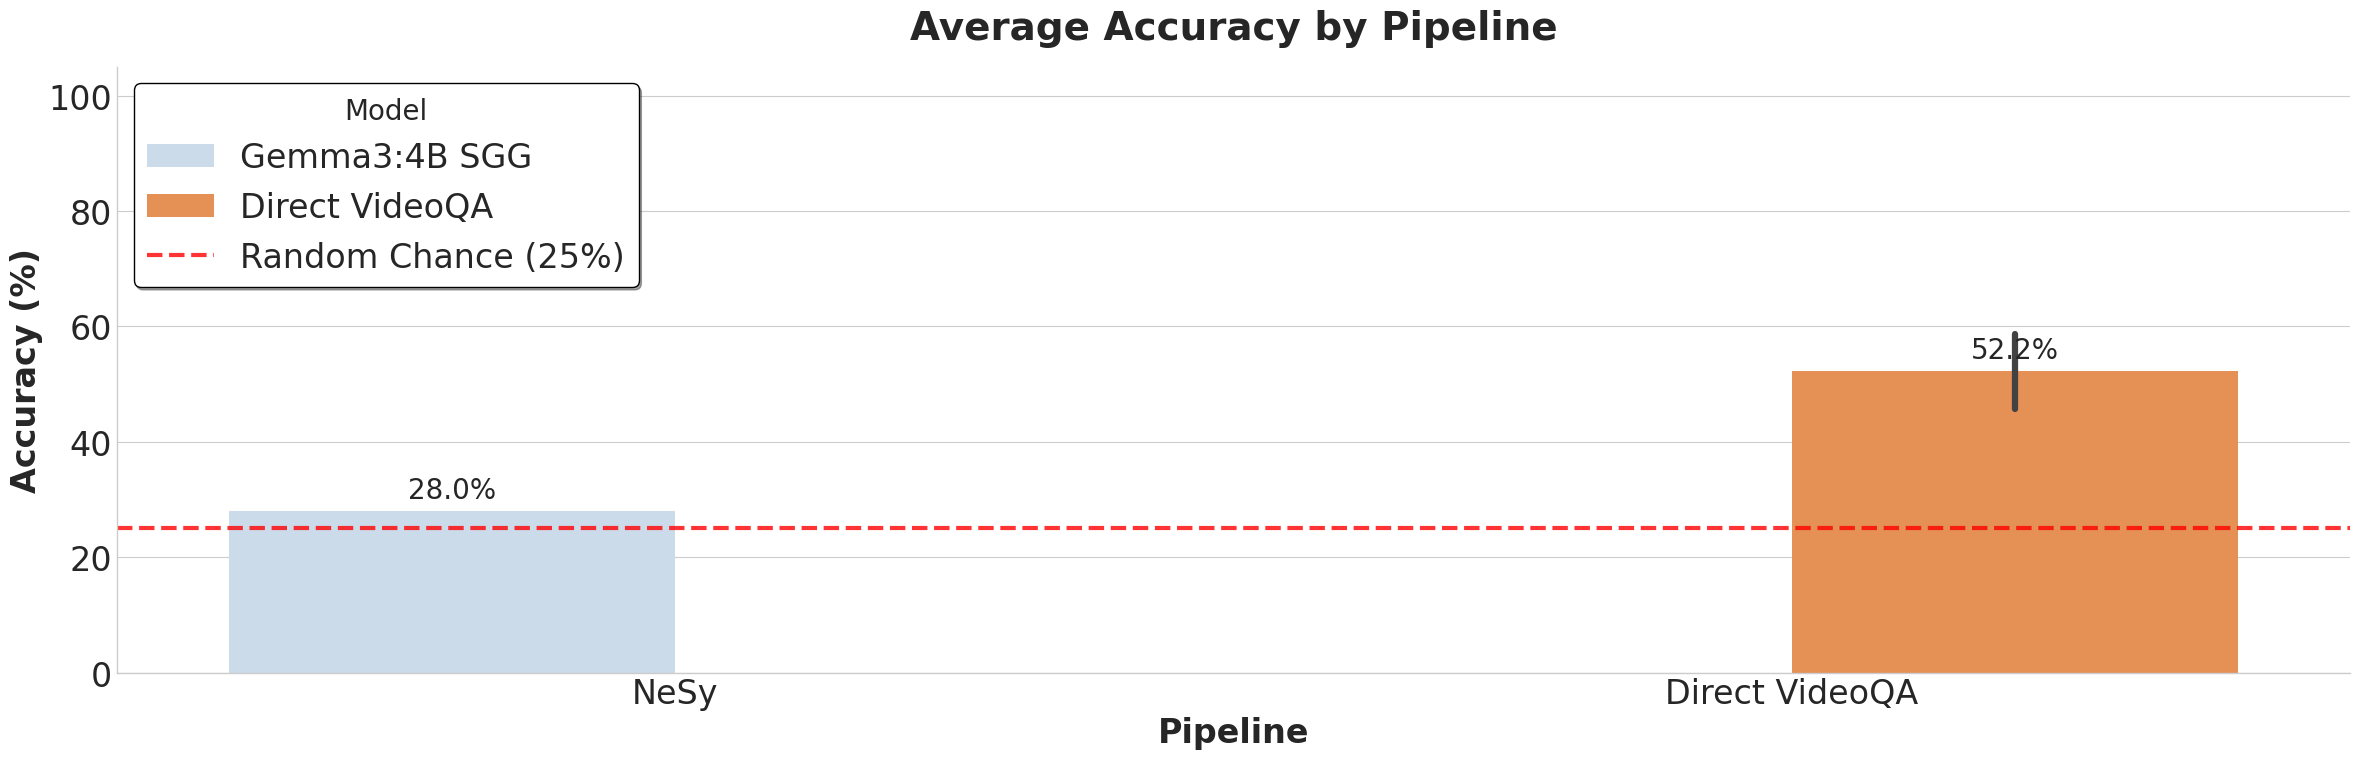

In [112]:
nesy_models = ["Gemma3:4B SGG"]
plot_ne_sy_vs_vqa(df, nesy_models_to_include=nesy_models, outfile_suffix='ne_sy_gemma_only_with_vqa')


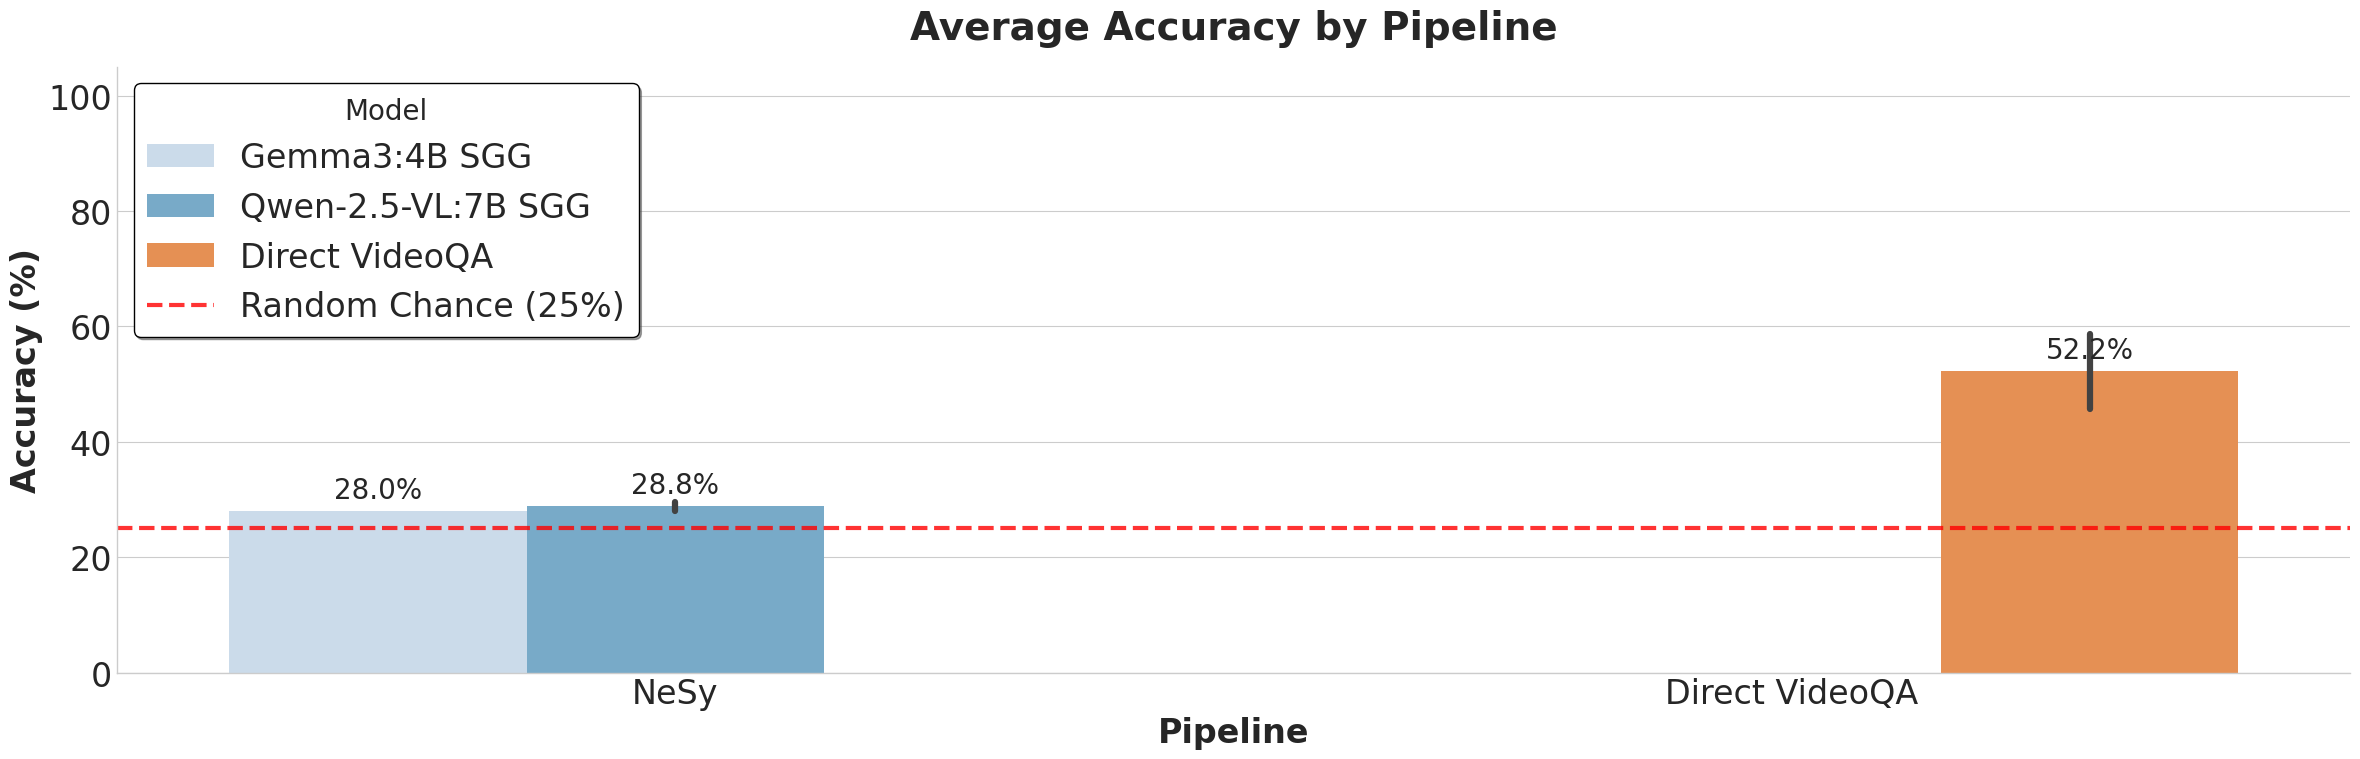

In [113]:
nesy_models = ["Gemma3:4B SGG", "Qwen-2.5-VL:7B SGG"]
plot_ne_sy_vs_vqa(df, nesy_models_to_include=nesy_models, outfile_suffix='ne_sy_gemma_qwen_with_vqa')


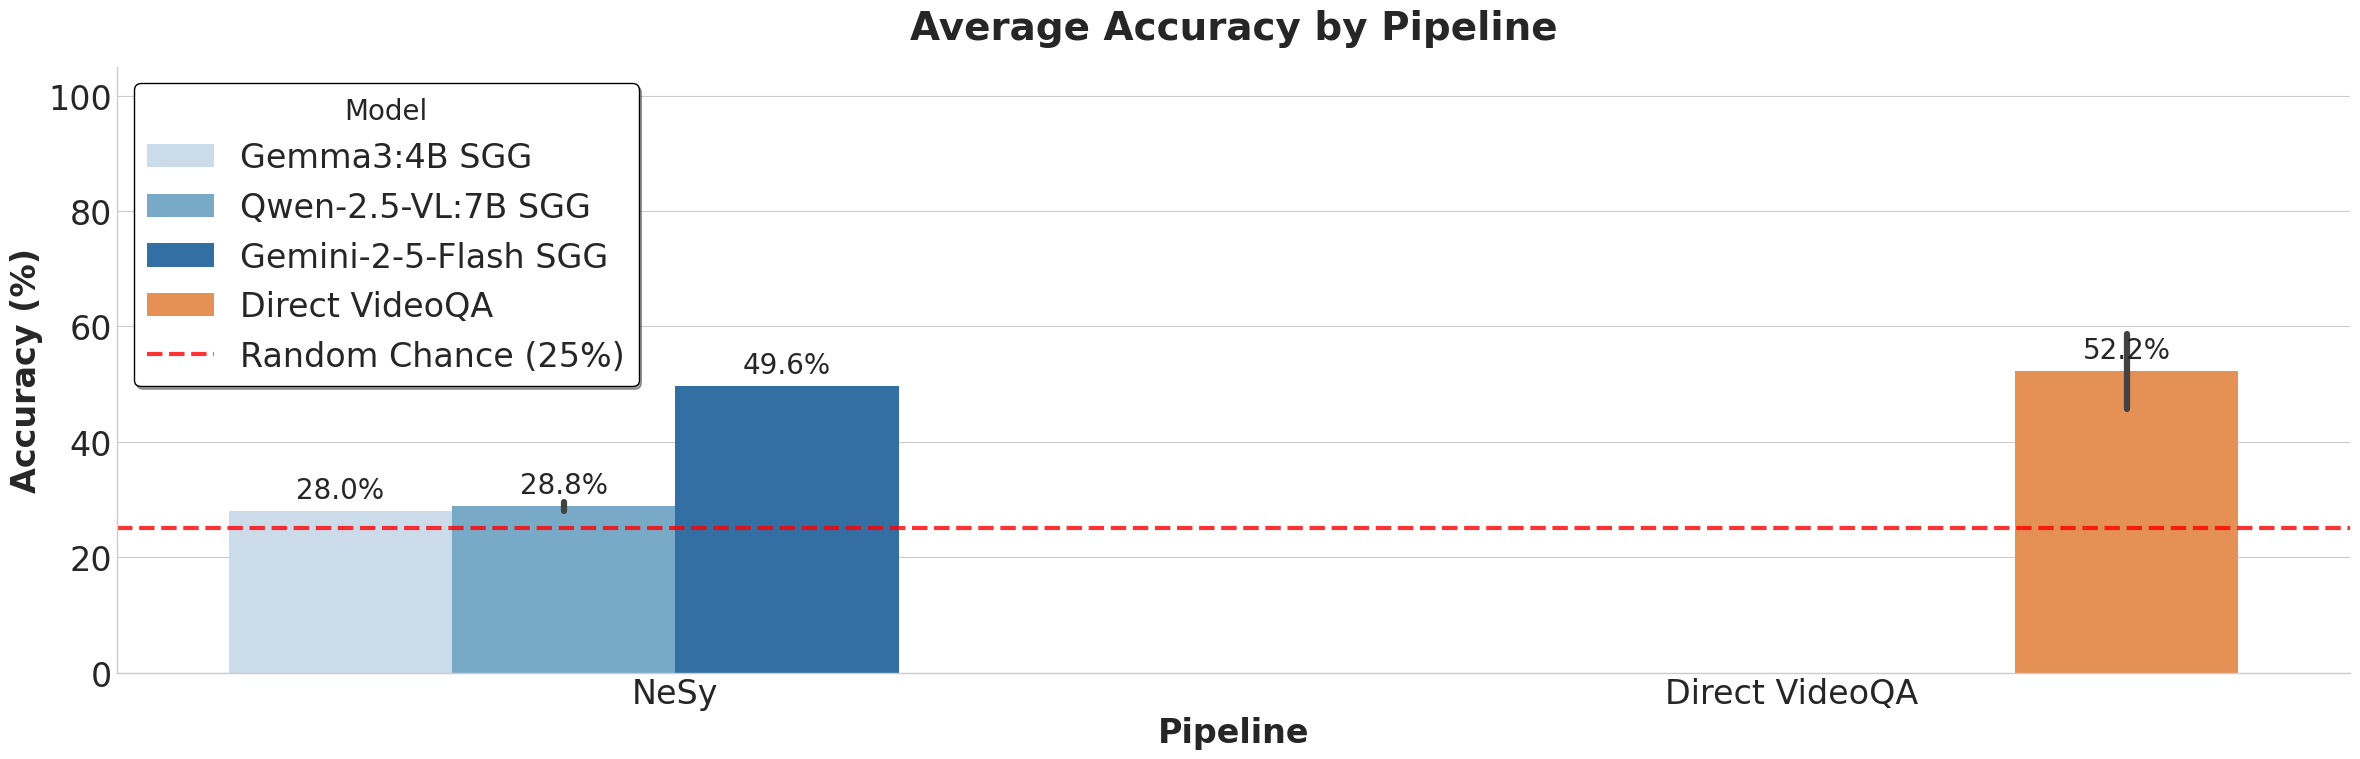

In [114]:
nesy_models = ["Gemma3:4B SGG", "Qwen-2.5-VL:7B SGG", "Gemini-2-5-Flash SGG"]
plot_ne_sy_vs_vqa(df, nesy_models_to_include=nesy_models, outfile_suffix='ne_sy_gemma_qwen_gemini_with_vqa')


## Gemini Entire validation set

In [263]:
STAR_VAL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val.json"
with open(STAR_VAL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7098 entries, Interaction_T1_13 to Feasibility_T6_1468
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          7098 non-null   object 
 1   video_id          7098 non-null   object 
 2   start             7098 non-null   float64
 3   end               7098 non-null   float64
 4   text              7098 non-null   object 
 5   question_program  7098 non-null   object 
 6   choices           7098 non-null   object 
 7   situations        7098 non-null   object 
dtypes: float64(2), object(6)
memory usage: 499.1+ KB


In [264]:
PATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_val_full_gemini_stsg_20250916.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="ollama")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["Gemini2"] = [
    {
        "model_name": "Gemma3:4B",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "support": {
            **eval_df.groupby(by=lambda x: x.split("_")[0])['contains_answer'].sum().to_dict(), 
            "Average": eval_df['contains_answer'].sum()
            },
        "support_ratio": rp.print_ans_perc(eval_df[eval_df['contains_answer']], gt_df),
        "model_size": 4,
    }
]


Total answers: 7035
Answers following JSON template: 7033
Percentage following JSON template: 99.97%
2025-10-24 10:07:05,811 - data_preprocessing - WARNING - Error executing eval on: {"answer": "None of the alternatives (A, B, C, or D) can be supported by the provided Spatio-Temporal Scene Graph. There is no information in the scene graph to answer the question \What happened after the person closed the door?\"}.
Answer with a valid alternative: 6782
96.43% of the total

Invalid answers: 251
Question type       Total      Accuracy 

Interaction         2398        52.34%  
Sequence            3586        54.77%  
Prediction           624        44.07%  
Feasibility          490        42.45%  

Average             7098        52.16%  
Question type       Total      Accuracy 

Interaction         2315        54.21%  
Sequence            3393        57.88%  
Prediction           602        45.68%  
Feasibility          472        44.07%  

Average             6782        54.59%  
Questio

/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
/tmp/ipykernel_272562/3031154834.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df['contains_answer'].fillna(False).astype(bool)


In [265]:
PATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_val_full_gemini_stsg_20250916_08:14:00.jsonl"

predictions_df = rp.ans_extract(PATH, "gemma3", format="ollama")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["Gemini2"].append(
    {
        "model_name": "Gemma3:12B",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "support": {
            **eval_df.groupby(by=lambda x: x.split("_")[0])['contains_answer'].sum().to_dict(), 
            "Average": eval_df['contains_answer'].sum()
            },
        "support_ratio": rp.print_ans_perc(eval_df[eval_df['contains_answer']], gt_df),
        "model_size": 12,
    }
)


Total answers: 7035
Answers following JSON template: 7034
Percentage following JSON template: 99.99%
Answer with a valid alternative: 6337
90.09% of the total

Invalid answers: 697
Question type       Total      Accuracy 

Interaction         2398        57.46%  
Sequence            3586        58.95%  
Prediction           624        49.52%  
Feasibility          490        47.35%  

Average             7098        56.82%  
Question type       Total      Accuracy 

Interaction         2173        63.41%  
Sequence            3167        66.75%  
Prediction           547        56.49%  
Feasibility          450        51.56%  

Average             6337        63.64%  
Question type       Total      Answered 

Interaction         2398        90.62%  
Sequence            3586        88.32%  
Prediction           624        87.66%  
Feasibility          490        91.84%  
Overall             7098        89.28%  


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
/tmp/ipykernel_272562/3653289763.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df['contains_answer'].fillna(False).astype(bool)


In [266]:
PATH = Path("/megaverse/storage/lusha/graph_und/aggregated_final_gu_gemini_val_20250917_08:18:00.jsonl")

predictions_df = rp.ans_extract(PATH, "gemma3", format="gemini")
predictions_df.rename(columns={'answer': 'pred_text'}, inplace=True)

eval_df = gt_df.join(
    predictions_df, 
    how='left' # we account also for samples without answers
)

eval_df['contains_answer'] = (
    eval_df['contains_answer'].fillna(False).astype(bool)
)
eval_df['pred_text'] = (
    eval_df['pred_text'].fillna("").astype(str)
)

model_preds["Gemini2"].append(
    {
        "model_name": "Gemini2.5flash",
        "predictions_df": predictions_df,
        "eval_df": eval_df,
        "accuracy": rp.print_acc(eval_df),
        "accuracy_contains_answer": rp.print_acc(eval_df[eval_df['contains_answer']]),
        "support": {
            **eval_df.groupby(by=lambda x: x.split("_")[0])['contains_answer'].sum().to_dict(), 
            "Average": eval_df['contains_answer'].sum()
            },
        "support_ratio": rp.print_ans_perc(eval_df[eval_df['contains_answer']], gt_df),
        "model_size": 30,
    }
)


Total answers: 6029
Answers following JSON template: 6029
Percentage following JSON template: 100.00%
2025-10-24 10:07:09,080 - data_preprocessing - WARNING - Error executing eval on: { "answer": "Based on the Spatio-Temporal Scene Graph (STSG):\n\n1.  **Question Interpretation:** The question asks to identify the specific action the man performed on the window before he picked up the rectangular object (assumed to be a book).\n\n2.  **STSG Analysis:**\n    *   In Frames 0-3, the STSG states: \man ---- standing_in_front_of ---- window\ and \man ---- interacting_with ---- window\. It also mentions \bright_light ---- visible_through ---- window\.\n    *   In Frames 4-5, the man is described as \bending_towards ---- floor\, \reaching_for ---- object\, and then \holding ---- rectangular_object\ and \lifting ---- rectangular_object ---- from ---- floor\. This is the action of taking the book.\n\n3.  **Alternative Evaluation:**\n    *   **A. Closed:** The STSG states the man was \interacting

/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
/tmp/ipykernel_272562/2026764431.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eval_df['contains_answer'].fillna(False).astype(bool)


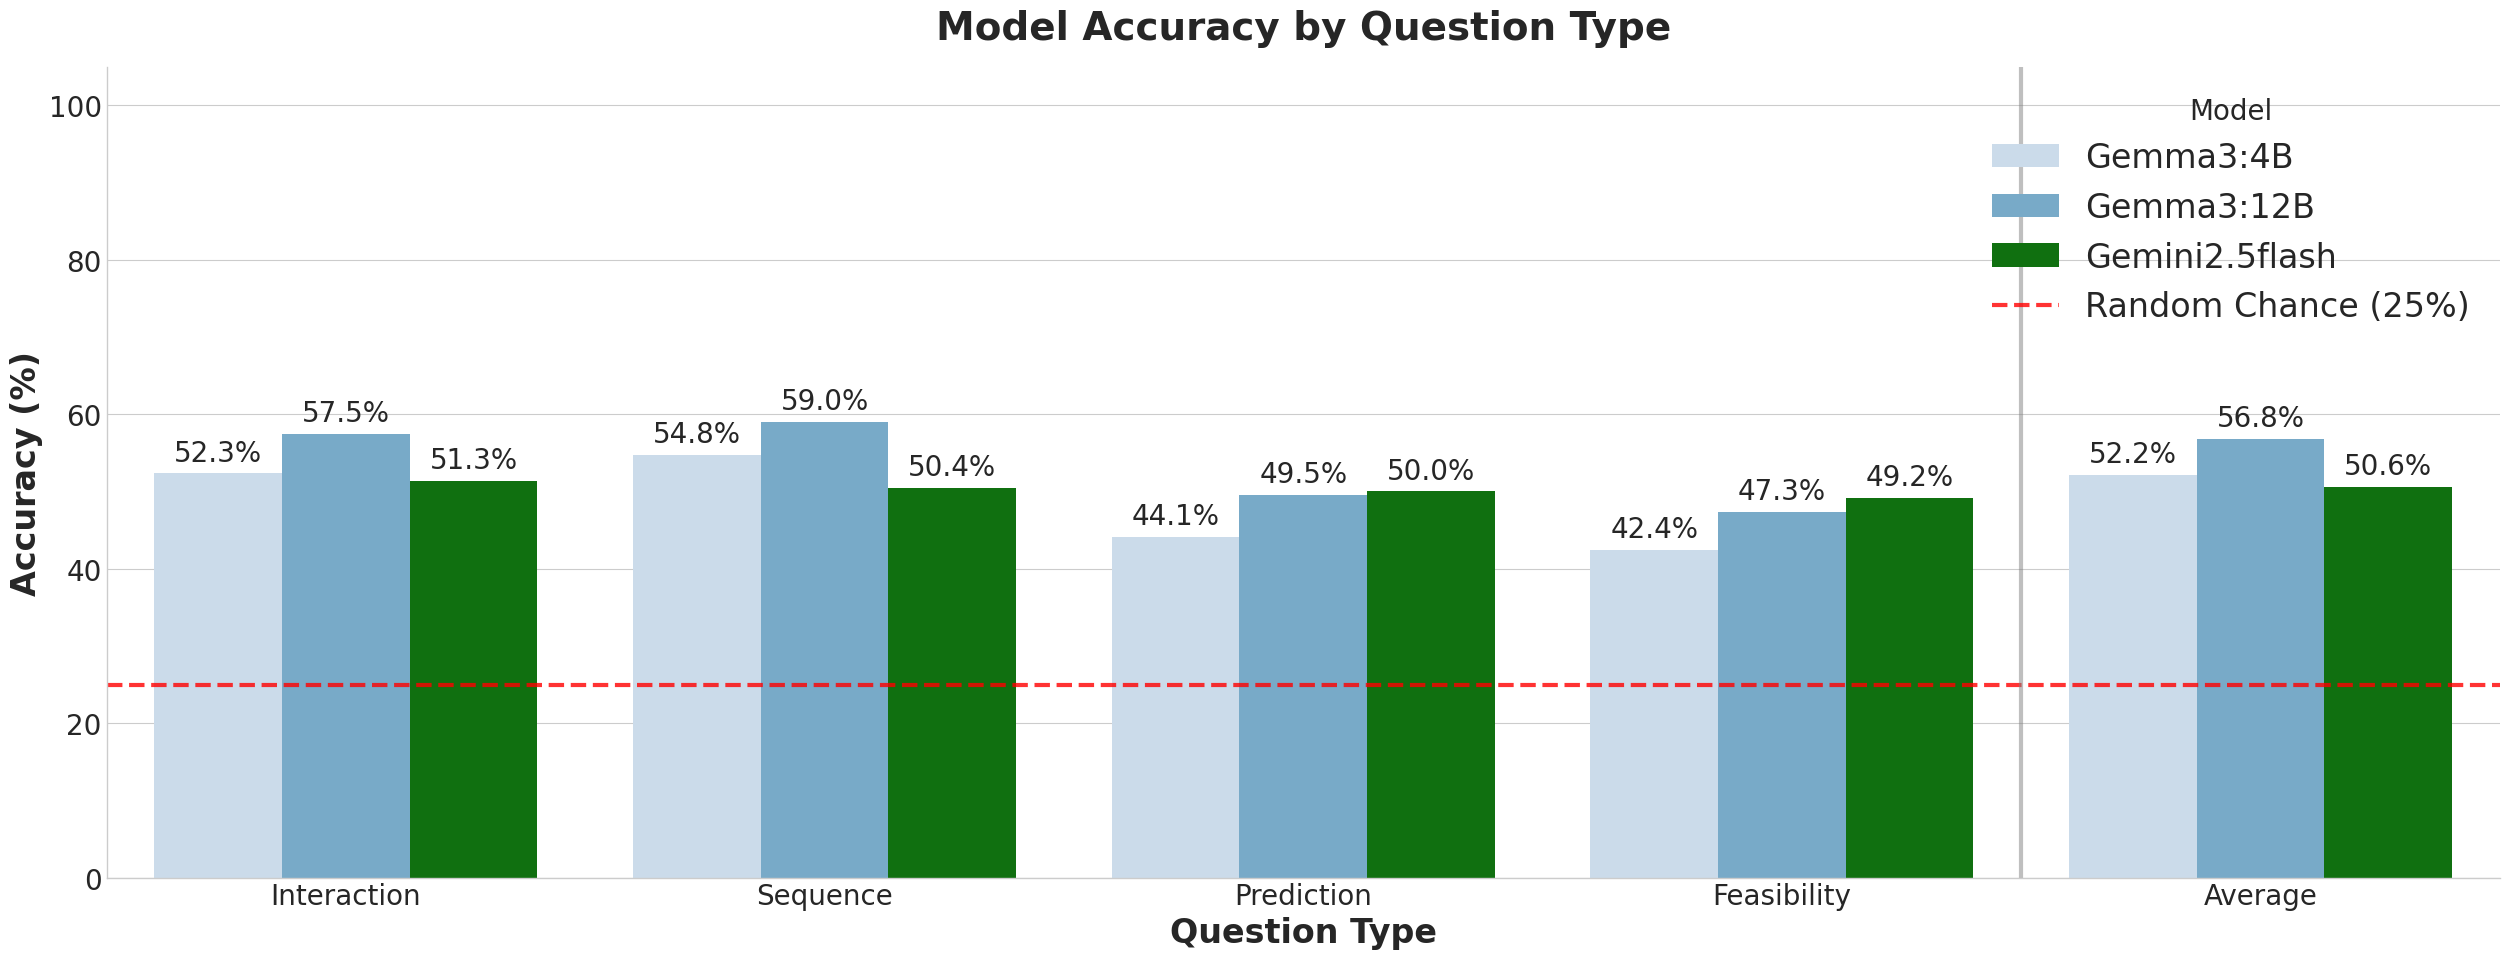

In [267]:
# Extract accuracy data with model size for ordering
data = []
model_sizes = {}

# Iterate through the list of Gemini models
for model_data in model_preds['Gemini2']:
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_key = model_data['model_name']
        model_sizes[model_key] = model_data['model_size']
        
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                data.append({
                    'Model': model_key,
                    'Question_Type': question_type,
                    'Accuracy': model_data['accuracy'][question_type] * 100, # Convert to percentage
                    'Model_Size': model_data['model_size']
                })

# Calculate average accuracy for each model across all question types
average_data = []
for model_data in model_preds['Gemini2']:
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_key = model_data['model_name']
        accuracies = []
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']:
            if question_type in model_data['accuracy']:
                accuracies.append(model_data['accuracy'][question_type] * 100)
        if accuracies:
            average_data.append({
                'Model': model_key,
                'Question_Type': 'Average',
                'Accuracy': model_data['accuracy'][question_type] * 100,
                'Model_Size': model_data['model_size']
            })

# Combine original data with average data
all_data = data + average_data
df = pd.DataFrame(all_data)

# Sort models by size (since we only have Gemini models now)
def model_sort_key(model_name):
    return model_sizes[model_name]

sorted_models = sorted(model_sizes.keys(), key=model_sort_key)
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create custom color palette for Gemini models
# Separate VideoQA models from non-VideoQA models
vqa_models = [model for model in sorted_models if 'VideoQA' in model]
non_vqa_models = [model for model in sorted_models if 'VideoQA' not in model]

# Use 'Oranges' colormap for VideoQA models, 'Blues' for non-VideoQA models
vqa_colors = sns.color_palette('Oranges', n_colors=len(vqa_models)) if vqa_models else []
non_vqa_colors = sns.color_palette('Blues', n_colors=len(non_vqa_models)) if non_vqa_models else []

# Create a dictionary mapping model names to colors
color_dict = {}
for i, model in enumerate(vqa_models):
    color_dict[model] = vqa_colors[i]
for i, model in enumerate(non_vqa_models):
    color_dict[model] = non_vqa_colors[i]

color_dict['Gemini2.5flash'] = 'Green'
# Create palette in the order of sorted_models
custom_palette = [color_dict[model] for model in sorted_models]

# Create grouped bar plot with Average
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots()#figsize=(18,9))
sns.barplot(data=df, x='Question_Type', y='Accuracy', hue='Model',
            palette=custom_palette, ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average'])

# Add random chance baseline (25%)
ax.axhline(y=25, color='red', linestyle='--',  alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average
ax.axvline(x=3.5, color='gray', linestyle='-',  alpha=0.5)

# Styling
ax.set_title('Model Accuracy by Question Type', fontweight='bold', pad=20)
ax.set_xlabel('Question Type',)
ax.set_ylabel('Accuracy (%)',)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title='Model', loc='upper right')

plt.tight_layout()
plt.savefig('endtoend_valset_gemini_model_accuracy.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


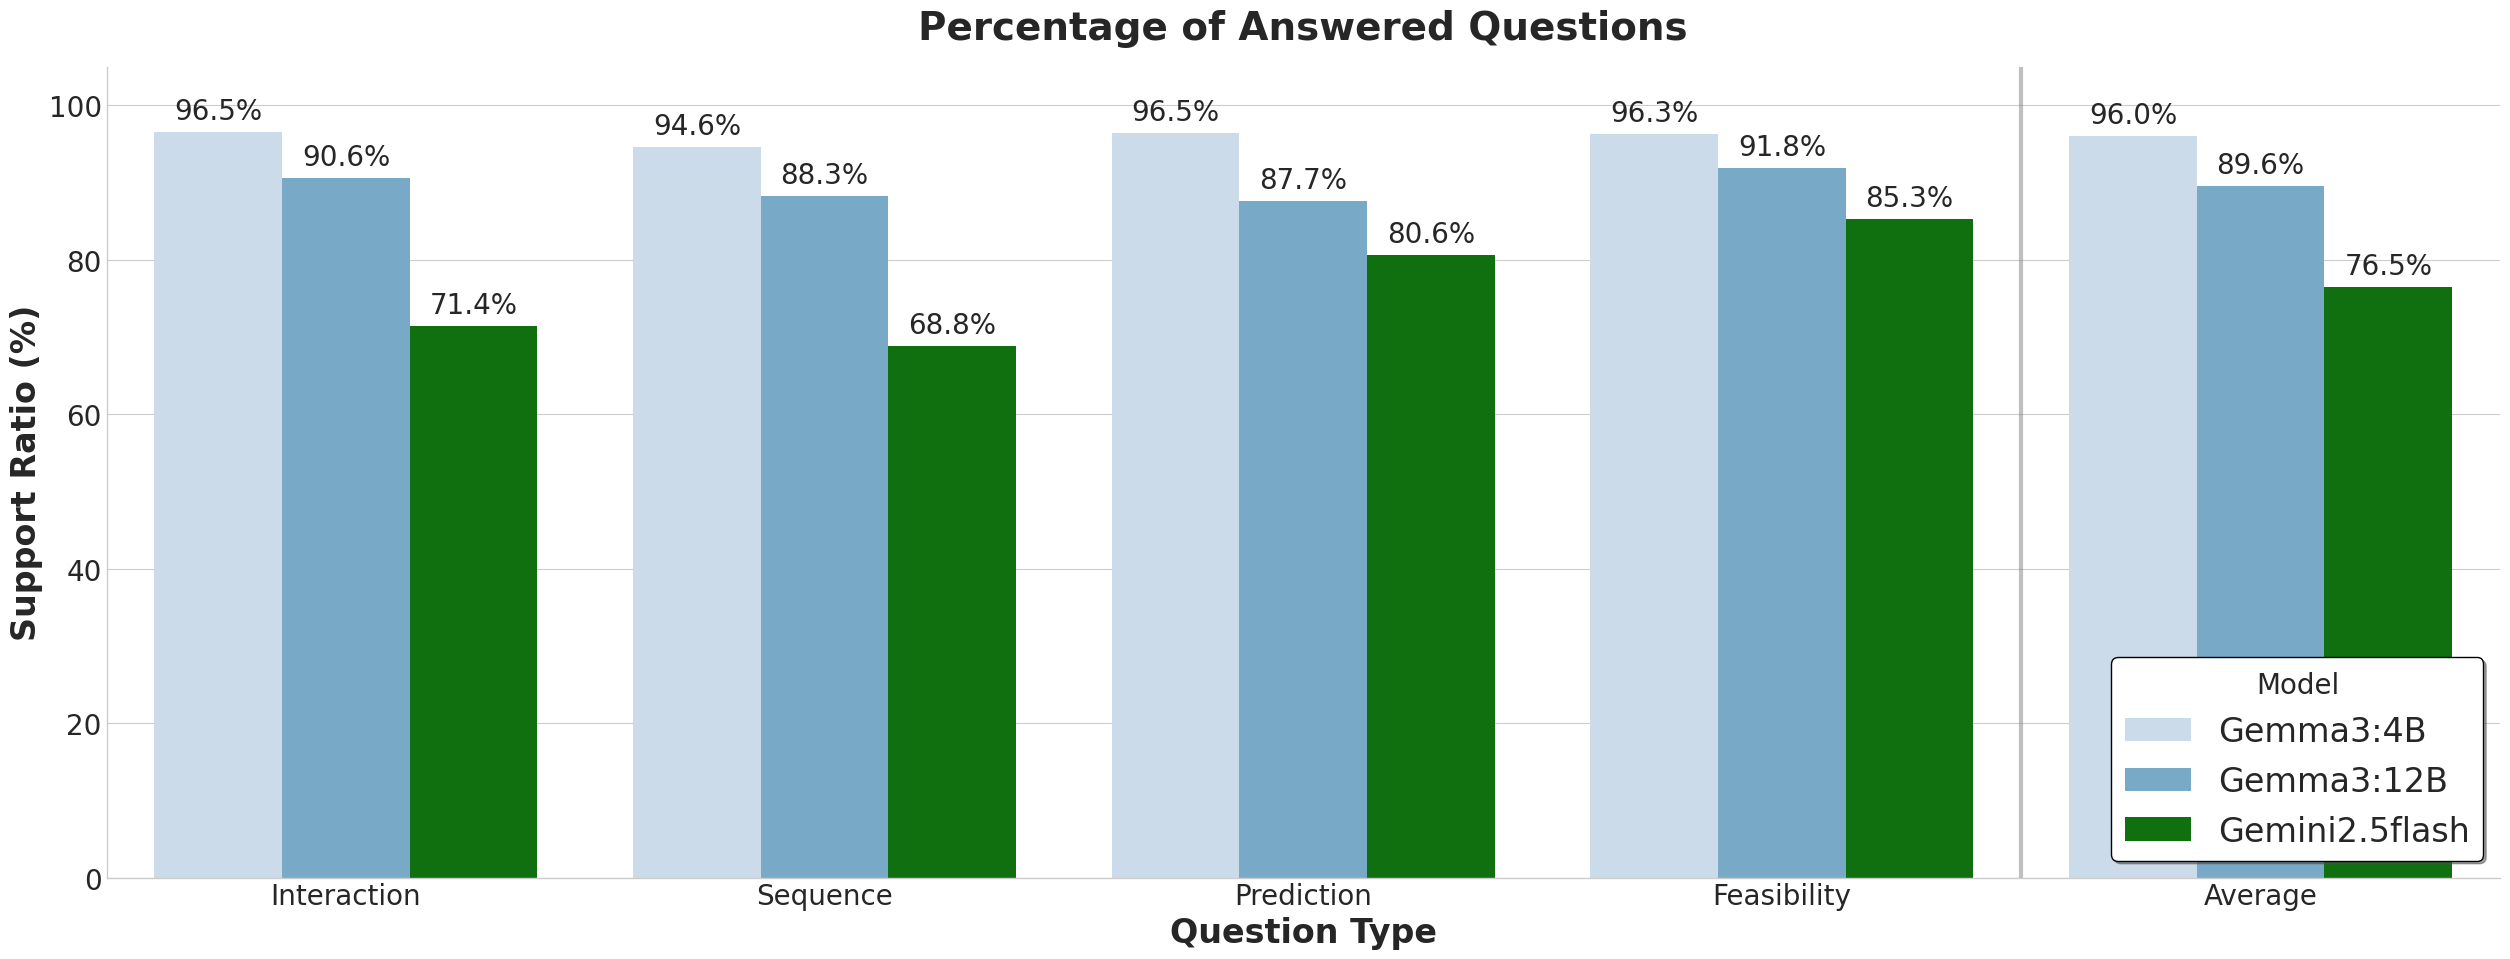

In [268]:
# Extract support ratio data with model size for ordering
data = []
model_sizes = {}

# Iterate through the list of Gemini models
for model_data in model_preds['Gemini2']:
    if isinstance(model_data, dict) and 'support_ratio' in model_data:
        model_key = model_data['model_name']
        model_sizes[model_key] = model_data['model_size']
        
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['support_ratio']:
                data.append({
                    'Model': model_key,
                    'Question_Type': question_type,
                    'Support_Ratio': model_data['support_ratio'][question_type] * 100, # Convert to percentage
                    'Model_Size': model_data['model_size']
                })

# Calculate average support ratio for each model across all question types
average_data = []
for model_data in model_preds['Gemini2']:
    if isinstance(model_data, dict) and 'support_ratio' in model_data:
        model_key = model_data['model_name']
        support_ratios = []
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['support_ratio']:
                support_ratios.append(model_data['support_ratio'][question_type] * 100)
        if support_ratios:
            # Calculate average support ratio
            avg_support_ratio = sum(support_ratios) / len(support_ratios)
            average_data.append({
                'Model': model_key,
                'Question_Type': 'Average',
                'Support_Ratio': avg_support_ratio,
                'Model_Size': model_data['model_size']
            })

# Combine original data with average data
all_data = data + average_data
df = pd.DataFrame(all_data)

# Sort models by size (since we only have Gemini models now)
def model_sort_key(model_name):
    return model_sizes[model_name]

sorted_models = sorted(model_sizes.keys(), key=model_sort_key)
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create custom color palette for Gemini models
# Separate VideoQA models from non-VideoQA models
vqa_models = [model for model in sorted_models if 'VideoQA' in model]
non_vqa_models = [model for model in sorted_models if 'VideoQA' not in model]

# Use 'Oranges' colormap for VideoQA models, 'Blues' for non-VideoQA models
vqa_colors = sns.color_palette('Oranges', n_colors=len(vqa_models)) if vqa_models else []
non_vqa_colors = sns.color_palette('Blues', n_colors=len(non_vqa_models)) if non_vqa_models else []

# Create a dictionary mapping model names to colors
color_dict = {}
for i, model in enumerate(vqa_models):
    color_dict[model] = vqa_colors[i]
for i, model in enumerate(non_vqa_models):
    color_dict[model] = non_vqa_colors[i]

color_dict['Gemini2.5flash'] = 'Green'
# Create palette in the order of sorted_models
custom_palette = [color_dict[model] for model in sorted_models]

# Create grouped bar plot with Average
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots()#figsize=(18,9))
sns.barplot(data=df, x='Question_Type', y='Support_Ratio', hue='Model',
            palette=custom_palette, ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average'])

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average
ax.axvline(x=3.5, color='gray', linestyle='-',  alpha=0.5)

# Styling
ax.set_title('Percentage of Answered Questions', fontweight='bold', pad=20)
ax.set_xlabel('Question Type',)
ax.set_ylabel('Support Ratio (%)',)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend with white background frame
handles, labels = ax.get_legend_handles_labels()
legend = plt.legend(handles, labels, title='Model', loc='lower right',
                   frameon=True, fancybox=True, shadow=True, 
                   facecolor='white', edgecolor='black', framealpha=1)

plt.tight_layout()
plt.savefig('endtoend_valset_gemini_ans_perc.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


## Gemini: NeSy vs Direct VideoQA

In [269]:
gemini_nesy = model_preds['Gemini'][2]
gemini_vqa = model_preds['Gemini'][3]

gemini_nesy_pred_df = gemini_nesy['predictions_df']
gemini_vqa_pred_df = gemini_vqa['predictions_df']

eval_df_all = gt_df.join(
    gemini_vqa_pred_df[gemini_vqa_pred_df['contains_answer']].rename(columns={'pred_text': 'pred_text1'})[['pred_text1']],
    how='inner'
).join(
    gemini_nesy_pred_df[gemini_nesy_pred_df['contains_answer']].rename(columns={'pred_text': 'pred_text2'})[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Interaction_T1_100,Which object was tidied up by the person?,the blanket.,the blanket.,the blanket.
Interaction_T1_101,Which object was put down by the person?,the box.,the box.,the box.
Interaction_T1_111,Which object was closed by the person?,the closet/cabinet.,the closet/cabinet.,the closet/cabinet.
Interaction_T1_148,Which object was sat on by the person?,the floor.,the floor.,the floor.
Interaction_T1_235,Which object was put down by the person?,the picture.,the picture.,the picture.
...,...,...,...,...
Feasibility_T6_1391,What is the person able to do after sitting on...,put down the broom.,put down the broom.,put down the broom.
Feasibility_T6_1392,What is the person able to do after sitting at...,put down the broom.,put down the broom.,put down the broom.
Feasibility_T6_1403,What is the person able to do after putting do...,throw the blanket.,sit on the sofa/couch.,sit on the sofa/couch.
Feasibility_T6_1412,What is the person able to do after walking th...,hold the book.,put down the cup/glass/bottle.,put down the cup/glass/bottle.


Question types found: ['Interaction' 'Sequence' 'Prediction' 'Feasibility']


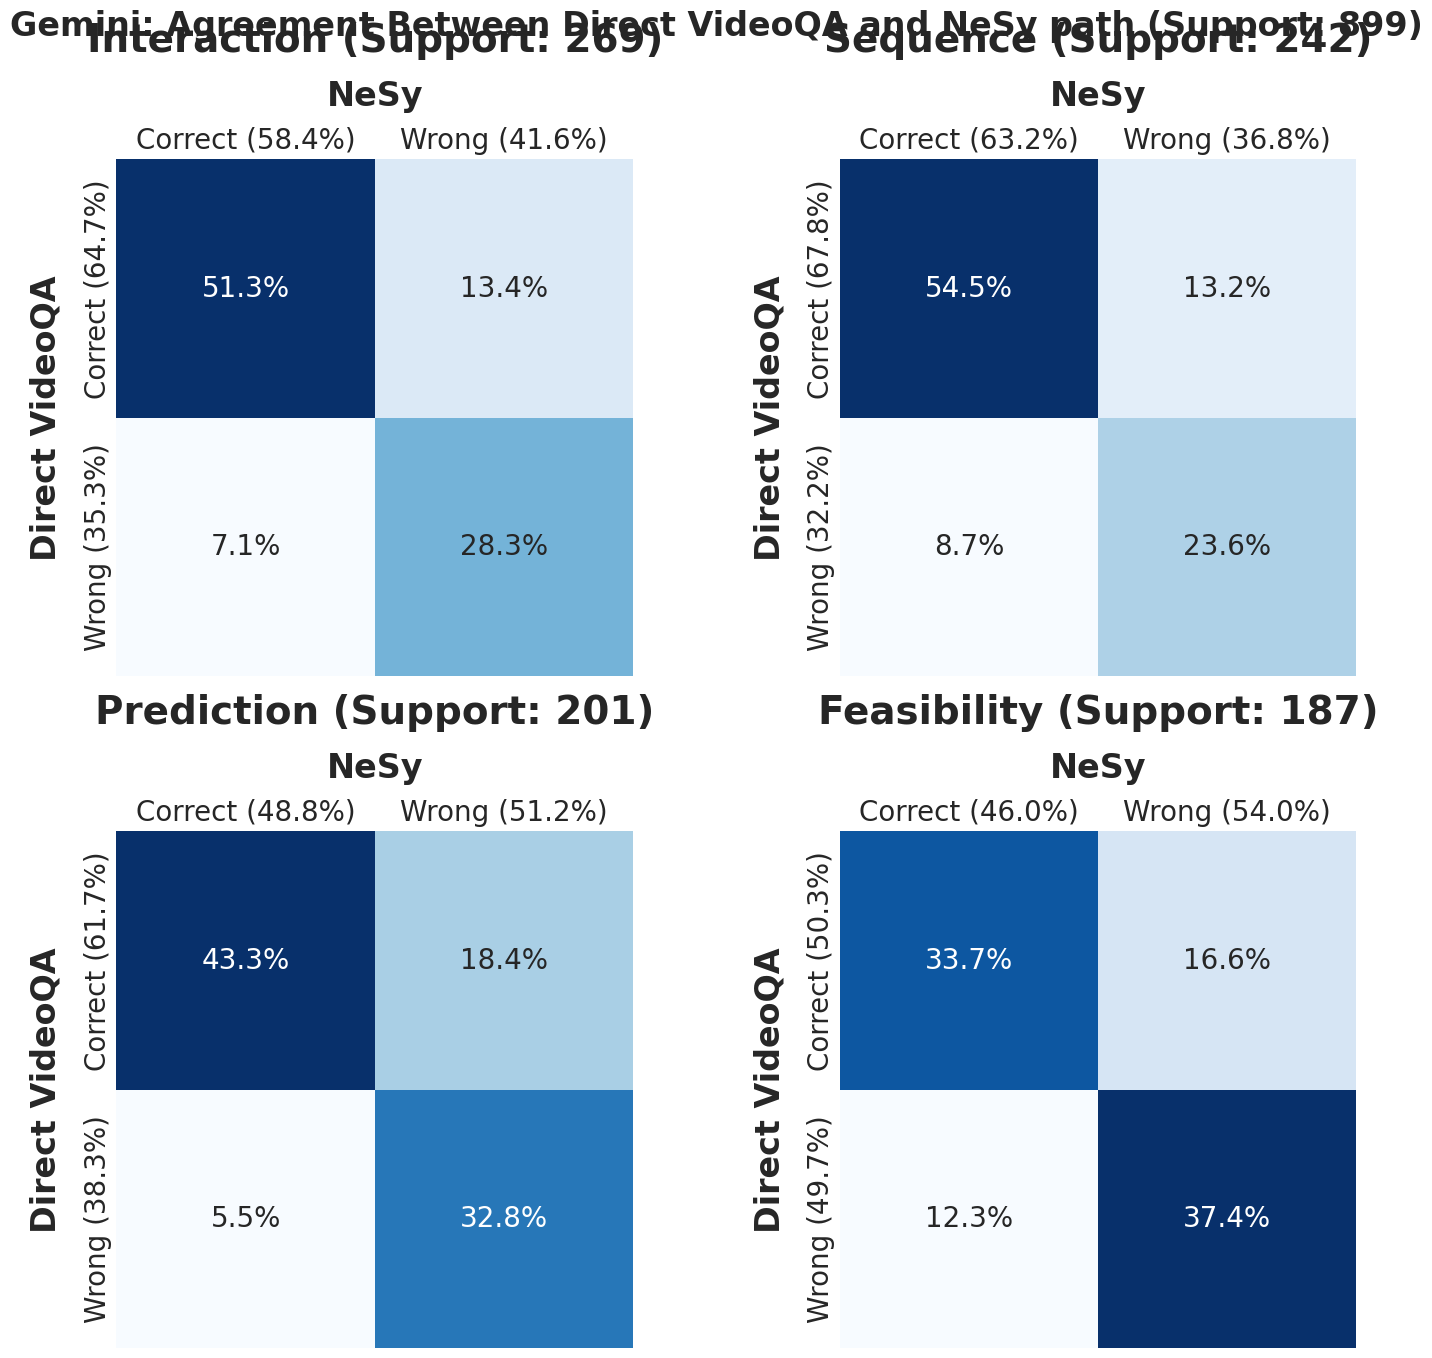

In [270]:
# --- YOUR ORIGINAL SETUP ---
viz_df = eval_df_all.copy()
viz_df['question_type'] = viz_df.index.str.split('_').str[0]
question_types = viz_df['question_type'].unique()

print("Question types found:", question_types)  # ← ADD THIS TO DEBUG

# If this prints empty or unexpected types, that's the issue!

labels = ['Correct', 'Wrong']

# Create subplots ONLY if you have data
if len(question_types) == 0:
    raise ValueError("No question types found! Check your index format.")

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
fig.suptitle(f'Gemini: Agreement Between Direct VideoQA and NeSy path (Support: {eval_df_all.shape[0]})', y=0.96, fontweight='bold')
plt.subplots_adjust(hspace=0.2, wspace=0.4)

axes = axes.flatten()

for i, qtype in enumerate(question_types[:4]):  # limit to 4 to fit 2x2 grid
    subset = viz_df[viz_df['question_type'] == qtype]
    if subset.empty:
        continue
        
    pred_vqa_wrong = (subset['text'] != subset['pred_text1']).astype(int).values
    pred_gg_wrong = (subset['text'] != subset['pred_text2']).astype(int).values
    
    cm = confusion_matrix(pred_vqa_wrong, pred_gg_wrong, normalize='all')
    
    # Marginals
    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)
    
    # Enhanced labels with marginals
    y_labels = [f"Correct ({row_totals[0]:.1%})", f"Wrong ({row_totals[1]:.1%})"]
    x_labels = [f"Correct ({col_totals[0]:.1%})", f"Wrong ({col_totals[1]:.1%})"]
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        xticklabels=x_labels,
        yticklabels=y_labels,
        cbar=False,
        ax=axes[i],
        square=True
    )
    
    axes[i].set_title(f"{qtype} (Support: {eval_df_all.index.str.startswith(qtype).sum()})", fontweight='bold', pad=20)
    axes[i].set_xlabel('NeSy', fontweight='bold', labelpad=15)
    axes[i].set_ylabel('Direct VideoQA', fontweight='bold', labelpad=15)
    axes[i].xaxis.set_ticks_position('top')
    axes[i].xaxis.set_label_position('top')

# Hide unused subplots if fewer than 4 question types
for j in range(i+1, 4):
    axes[j].set_visible(False)

plt.savefig('endtoend_gemini_cm.svg', format='svg', dpi=300)
plt.show()


In [271]:
eval_df_all.index.str.startswith(qtype).sum() 


187